In [1]:
# ======================================================================
# Mobile Price Range — Full EDA + Univarient + Bivarient + Multi-varient
# Author: (replace with your name)
# Purpose: Complete Exploratory Data Analysis with 12+ story questions
# Dataset assumed path: /kaggle/input/mobile-price-prediction-dataset/mobiles_prices_prediction.csv

import os
import sys
import math
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10,6)

import plotly.express as px
import plotly.graph_objects as go

from scipy import stats
from scipy.stats import ttest_ind, f_oneway, pearsonr
from statsmodels.nonparametric.smoothers_lowess import lowess

# Utility for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
# --------------------------
# SECTION 1 — FILES & PATHS 
# --------------------------
# Try common Kaggle paths; if not present, show message
cand_paths = [
    "/kaggle/input/mobile-price-prediction-dataset/mobiles_prices_prediction.csv",
    "/kaggle/input/mobile-price-prediction-dataset/mobiles_prices_prediction.csv".lower(),
    "/kaggle/input/mobiles-prices-prediction/mobiles_prices_prediction.csv",
    "/kaggle/input/mobile-price-classification/train.csv",
    "/mnt/data/mobiles_prices_prediction.csv",
    "/kaggle/input/mobile-price-prediction-dataset/mobiles_prices_prediction.csv"
]

DATA_PATH = None
for p in cand_paths:
    if os.path.exists(p):
        DATA_PATH = p
        break

if DATA_PATH is None:
    print("Dataset not found in expected Kaggle paths. Please upload dataset to /kaggle/input or update DATA_PATH.")
else:
    print("Dataset Load successfully.")
    print("Using dataset at:", DATA_PATH)


Dataset Load successfully.
Using dataset at: /kaggle/input/mobile-price-prediction-dataset/mobiles_prices_prediction.csv


In [3]:
# --------------------------
# SECTION 2 — LOAD DATA (safe)
# --------------------------
def load_mobile_df(path):
    df = pd.read_csv(path)
    # Normalize column names: trim, replace spaces with underscore
    df.columns = [c.strip().replace(' ', '_') for c in df.columns]
    return df

if DATA_PATH:
    df = load_mobile_df(DATA_PATH)
    print("Loaded dataframe with shape:", df.shape)
    display(df.head(5).T)
else:
    df = pd.DataFrame()


Loaded dataframe with shape: (533, 21)


,0,1,2,3,4
Category,Available,Available,Available,Available,Available
Model_URL,https://www.whatmobile.com.pk/Infinix_Zero-Flip,https://www.whatmobile.com.pk/Infinix_Note-50-...,https://www.whatmobile.com.pk/Infinix_Zero-30-5G,https://www.whatmobile.com.pk/Infinix_GT-20-Pro,https://www.whatmobile.com.pk/Infinix_Zero-40-5G
Price_PKR,234999,119999,99999,99999,89999
Image_URL,https://www.whatmobile.com.pk/admin/images/Inf...,https://www.whatmobile.com.pk/admin/images/Inf...,https://www.whatmobile.com.pk/admin/images/Inf...,https://www.whatmobile.com.pk/admin/images/Inf...,https://www.whatmobile.com.pk/admin/images/Inf...
Model_Title,Infinix Zero Flip,Infinix Note 50 Pro Plus,Infinix Zero 30 5G,Infinix GT 20 Pro,Infinix Zero 40 5G
OS,14,15,13,14,14
UI,XOS,XOS,XOS,XOS,XOS
weight_in_g,195,209,185,194,195
5G_Band,Yes,Yes,Yes,Yes,Yes
NFC,Yes,Yes,Yes,Yes,Yes


# Data Checking 

In [4]:
df.head()


,Category,Model_URL,Price_PKR,Image_URL,Model_Title,OS,UI,weight_in_g,5G_Band,NFC,...,gpu_category,Amoled_display,refresh_rate_hz,storage_gb,ram_gb,main_camera_max_MP,4K_or_More_supportive,front_camer_max_MP,Type_C_supportive,battery_mAh
0,Available,https://www.whatmobile.com.pk/Infinix_Zero-Flip,234999,https://www.whatmobile.com.pk/admin/images/Inf...,Infinix Zero Flip,14,XOS,195,Yes,Yes,...,Mali,Yes,120,512,8,50,Yes,50,Yes,4720
1,Available,https://www.whatmobile.com.pk/Infinix_Note-50-...,119999,https://www.whatmobile.com.pk/admin/images/Inf...,Infinix Note 50 Pro Plus,15,XOS,209,Yes,Yes,...,Mali,Yes,144,256,12,50,Yes,32,Yes,5200
2,Available,https://www.whatmobile.com.pk/Infinix_Zero-30-5G,99999,https://www.whatmobile.com.pk/admin/images/Inf...,Infinix Zero 30 5G,13,XOS,185,Yes,Yes,...,Mali,Yes,144,256,12,108,Yes,50,No,5000
3,Available,https://www.whatmobile.com.pk/Infinix_GT-20-Pro,99999,https://www.whatmobile.com.pk/admin/images/Inf...,Infinix GT 20 Pro,14,XOS,194,Yes,Yes,...,Mali,Yes,144,256,12,108,Yes,32,Yes,5000
4,Available,https://www.whatmobile.com.pk/Infinix_Zero-40-5G,89999,https://www.whatmobile.com.pk/admin/images/Inf...,Infinix Zero 40 5G,14,XOS,195,Yes,Yes,...,Mali,Yes,144,256,12,108,Yes,50,Yes,5000


In [5]:

print("Shape:", df.shape)


Shape: (533, 21)


In [6]:
print("\nColumns:\n", df.columns.tolist())



Columns:
 ['Category', 'Model_URL', 'Price_PKR', 'Image_URL', 'Model_Title', 'OS', 'UI', 'weight_in_g', '5G_Band', 'NFC', 'Brand', 'gpu_category', 'Amoled_display', 'refresh_rate_hz', 'storage_gb', 'ram_gb', 'main_camera_max_MP', '4K_or_More_supportive', 'front_camer_max_MP', 'Type_C_supportive', 'battery_mAh']


In [7]:
print("\nData types:\n")
display(df.dtypes)



Data types:



Category                 object
Model_URL                object
Price_PKR                 int64
Image_URL                object
Model_Title              object
OS                        int64
UI                       object
weight_in_g               int64
5G_Band                  object
NFC                      object
Brand                    object
gpu_category             object
Amoled_display           object
refresh_rate_hz           int64
storage_gb                int64
ram_gb                    int64
main_camera_max_MP        int64
4K_or_More_supportive    object
front_camer_max_MP        int64
Type_C_supportive        object
battery_mAh               int64
dtype: object

In [8]:
print("\nNull counts (top 20):")
display(df.isna().sum().sort_values(ascending=False).head(20))



Null counts (top 20):


Category                 0
gpu_category             0
Type_C_supportive        0
front_camer_max_MP       0
4K_or_More_supportive    0
main_camera_max_MP       0
ram_gb                   0
storage_gb               0
refresh_rate_hz          0
Amoled_display           0
Brand                    0
Model_URL                0
NFC                      0
5G_Band                  0
weight_in_g              0
UI                       0
OS                       0
Model_Title              0
Image_URL                0
Price_PKR                0
dtype: int64

In [9]:
print("\nDuplicate rows:", df.duplicated().sum())



Duplicate rows: 0


In [10]:
print("\nBasic describe (numerical):")
display(df.describe().T)



Basic describe (numerical):


,count,mean,std,min,25%,50%,75%,max
Price_PKR,533.0,86200.656660,98758.144155,10000.0,30999.0,49999.0,89999.0,654999.0
OS,533.0,12.106942,2.108390,6.0,11.0,12.0,14.0,16.0
weight_in_g,533.0,190.630394,19.146850,87.0,184.0,190.0,196.0,465.0
refresh_rate_hz,533.0,90.506567,27.763882,60.0,60.0,90.0,120.0,144.0
storage_gb,533.0,176.720450,129.068695,16.0,128.0,128.0,256.0,512.0
ram_gb,533.0,7.037523,3.387629,1.0,4.0,8.0,8.0,16.0
main_camera_max_MP,533.0,47.960600,35.940954,8.0,13.0,50.0,50.0,200.0
front_camer_max_MP,533.0,16.851782,12.685265,4.0,8.0,13.0,20.0,60.0
battery_mAh,533.0,4982.054409,686.461006,3000.0,4600.0,5000.0,5000.0,8000.0


In [11]:
print("\nBasic describe (categorical - top values):")
cat_cols = df.select_dtypes(include='object').columns.tolist()
for c in cat_cols:
    print("->", c, ":", df[c].nunique(), "unique values; top:", df[c].value_counts().head(3).to_dict())



Basic describe (categorical - top values):
-> Category : 2 unique values; top: {'Available': 503, 'Coming Soon': 30}
-> Model_URL : 533 unique values; top: {'https://www.whatmobile.com.pk/Infinix_Zero-Flip': 1, 'https://www.whatmobile.com.pk/Xiaomi_Redmi-15C': 1, 'https://www.whatmobile.com.pk/Xiaomi_Redmi-12C-128GB': 1}
-> Image_URL : 532 unique values; top: {'https://www.whatmobile.com.pk/admin/images/Xiaomi/XiaomiRedmiNote128GB-s.jpg': 2, 'https://www.whatmobile.com.pk/admin/images/Xiaomi/XiaomiRedmiA3-s.jpg': 1, 'https://www.whatmobile.com.pk/admin/images/Xiaomi/XiaomiPocoC75-s.jpg': 1}
-> Model_Title : 533 unique values; top: {'Infinix Zero Flip': 1, 'Xiaomi Redmi 15C': 1, 'Xiaomi Redmi 12C 128GB': 1}
-> UI : 18 unique values; top: {'OneUI': 102, 'XOS': 101, 'Funtouch': 85}
-> 5G_Band : 2 unique values; top: {'No': 370, 'Yes': 163}
-> NFC : 2 unique values; top: {'Yes': 270, 'No': 263}
-> Brand : 6 unique values; top: {'Xiaomi': 115, 'Samsung': 107, 'Infinix': 101}
-> gpu_categor

# Data Cleaning anf Preprocessing

In [12]:

def preprocess_mobile_df(df):
    df = df.copy()
    # drop columns that look like URLs
    url_like = [c for c in df.columns if 'url' in c.lower() or 'image' in c.lower()]
    if url_like:
        print("Dropping URL-like columns:", url_like)
        df = df.drop(columns=url_like, errors='ignore')

    # strip whitespace from string columns
    obj_cols = df.select_dtypes(include='object').columns.tolist()
    for c in obj_cols:
        df[c] = df[c].astype(str).str.strip()

    # boolean/binary columns mapping tolerant of Yes/No, 1/0, True/False
    possible_binary = ['5G_Band','5g_band','NFC','nfc','Amoled_display','amoled_display','Type_C_supportive','4K_or_More_supportive']
    for c in possible_binary:
        if c in df.columns:
            df[c] = df[c].replace({'Yes':1,'No':0,'yes':1,'no':0,'Y':1,'N':0, 'True':1, 'False':0})
            df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0).astype(int)

    # numeric conversion for numeric-like columns
    numeric_like = ['Price_PKR','price_pkr','weight_in_g','refresh_rate_hz','storage_gb','ram_gb',
                    'main_camera_max_MP','front_camer_max_MP','battery_mAh','battery_power','mobile_wt']
    for c in numeric_like:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    # drop exact duplicates
    before_dup = df.shape[0]
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Dropped {before_dup - df.shape[0]} exact duplicate rows.")

    # create a safe price column name if multiple naming variants exist
    if 'Price_PKR' not in df.columns and 'price_pkr' in df.columns:
        df['Price_PKR'] = df['price_pkr']

    # quick missing summary for reviewer
    miss = df.isna().sum()
    miss = miss[miss>0].sort_values(ascending=False)
    if not miss.empty:
        print("Columns with missing values (non-zero):")
        display(miss)
    else:
        print("No missing values detected after conversions.")

    return df

df = preprocess_mobile_df(df)


Dropping URL-like columns: ['Model_URL', 'Image_URL']
Dropped 0 exact duplicate rows.
No missing values detected after conversions.


# Explanation

*Cleaning steps are conservative and transparent: remove URL columns, normalize strings, map binary columns robustly, convert numeric-like columns, drop duplicates, and ensure Price_PKR present. Missing-values summary helps determine if imputation is needed.*

# Handling the Outliers (IQR-capping helper)

In [13]:

def cap_series_iqr(s, k=1.5):
    # Returns a capped Series (non-destructive)
    if s.dropna().shape[0] == 0:
        return s
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - k * iqr
    high = q3 + k * iqr
    return s.clip(lower=low, upper=high)

# Create capped versions for plotting (keep originals)
to_cap = [c for c in ['Price_PKR','weight_in_g','refresh_rate_hz','storage_gb','ram_gb','main_camera_max_MP','front_camer_max_MP','battery_mAh'] if c in df.columns]
for c in to_cap:
    df[c + "_capped"] = cap_series_iqr(df[c])
print("Created capped columns for:", to_cap)


Created capped columns for: ['Price_PKR', 'weight_in_g', 'refresh_rate_hz', 'storage_gb', 'ram_gb', 'main_camera_max_MP', 'front_camer_max_MP', 'battery_mAh']


# Explanation

*Outliers are capped with IQR method into new _capped columns. This avoids modifying originals while producing cleaner plots in the report.*

# CREATE PRICE_RANGE (quartiles)

In [14]:

if 'Price_PKR' in df.columns:
    try:
        df['price_range'] = pd.qcut(df['Price_PKR'], q=4, labels=['Budget','Mid-Range','High-End','Premium'])
        print("Created 'price_range' via quartiles.")
        display(df['price_range'].value_counts())
    except Exception as e:
        print("Could not create quartile price_range:", e)
else:
    print("Price column not found; cannot create price_range.")


Created 'price_range' via quartiles.


price_range
Budget       138
Mid-Range    138
Premium      131
High-End     126
Name: count, dtype: int64

# Explanation
*We create price_range with quartile labels as required for assignment. This categorical target is useful for bivariate and multivariate visuals.*

#  UTILITY PLOTTING FUNCTIONS

In [15]:

def set_labels(ax, xlabel=None, ylabel=None, title=None, legend=True):
    if xlabel: ax.set_xlabel(xlabel, fontsize=11)
    if ylabel: ax.set_ylabel(ylabel, fontsize=11)
    if title: ax.set_title(title, fontsize=13, weight='bold')
    if not legend:
        ax.get_legend().remove() if ax.get_legend() else None

def show_hist_kde(series, title=None, bins=30):
    fig, ax = plt.subplots(figsize=(8,4))
    sns.histplot(series.dropna(), bins=bins, kde=True, ax=ax)
    set_labels(ax, xlabel=series.name, ylabel='Count', title=title)
    plt.show()

def show_box(series, title=None):
    fig, ax = plt.subplots(figsize=(8,2.5))
    sns.boxplot(x=series.dropna(), ax=ax)
    set_labels(ax, xlabel=series.name, title=title)
    plt.show()

def show_violin(series, title=None):
    fig, ax = plt.subplots(figsize=(8,3))
    sns.violinplot(x=series.dropna(), ax=ax, inner='quartile')
    set_labels(ax, xlabel=series.name, title=title)
    plt.show()

def save_fig(fig, fname, dpi=150):
    fig.savefig(fname, bbox_inches='tight', dpi=dpi)
    print("Saved:", fname)


# Explanation
Reusable plotting functions keep the notebook tidy and help produce consistent visuals (labels, sizes).

# UNIVARIATE ANALYSIS Numeric

Numeric columns to analyze: ['Price_PKR', 'OS', 'weight_in_g', '5G_Band', 'NFC', 'Amoled_display', 'refresh_rate_hz', 'storage_gb', 'ram_gb', 'main_camera_max_MP', '4K_or_More_supportive', 'front_camer_max_MP', 'Type_C_supportive', 'battery_mAh', 'Price_PKR_capped', 'weight_in_g_capped', 'refresh_rate_hz_capped', 'storage_gb_capped', 'ram_gb_capped', 'main_camera_max_MP_capped', 'front_camer_max_MP_capped', 'battery_mAh_capped']
Price stats: {'mean': 86200.66, 'median': 49999.0, 'std': 98758.14, 'min': 10000, 'max': 654999, 'skew': 2.83, 'kurtosis': 9.31}


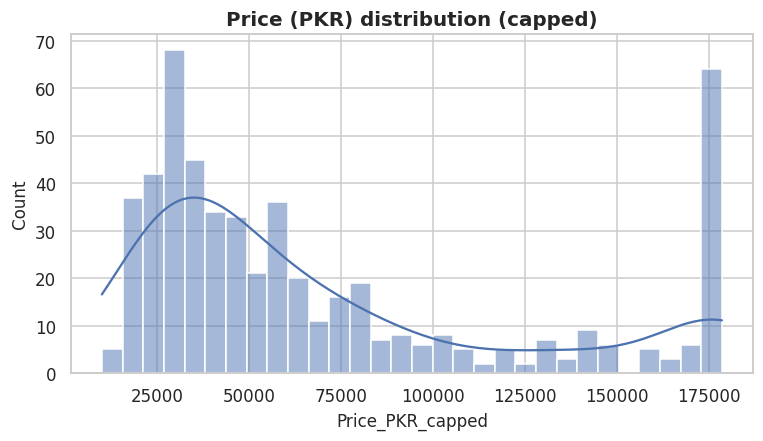


----- OS -----
Count non-null: 533
Mean: 12.11 Median: 12.0


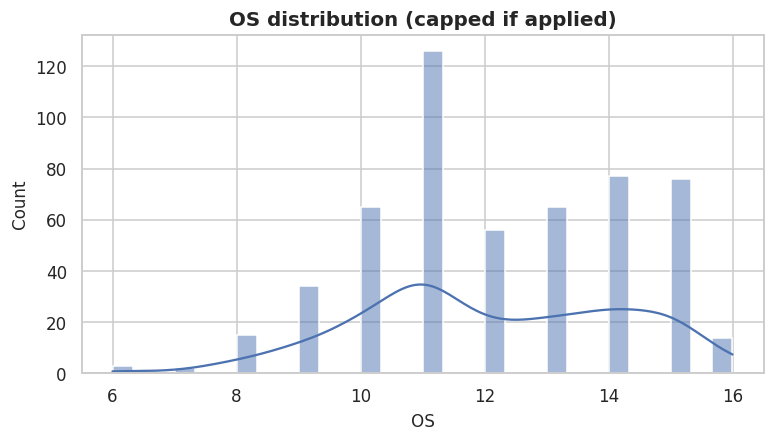

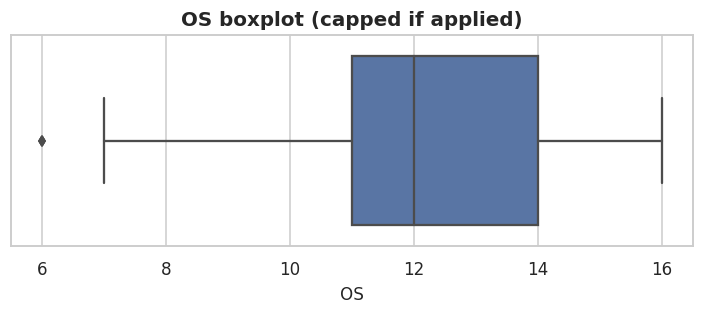

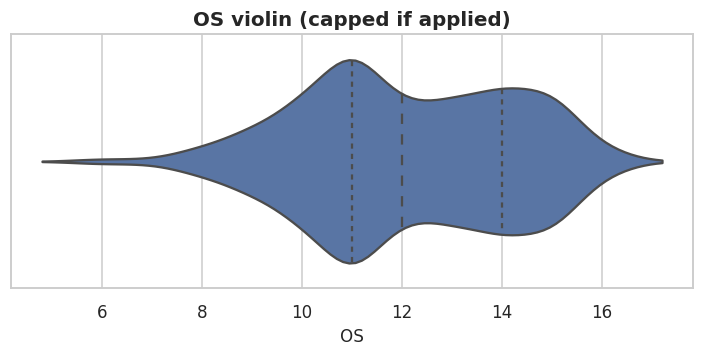


----- weight_in_g -----
Count non-null: 533
Mean: 190.63 Median: 190.0


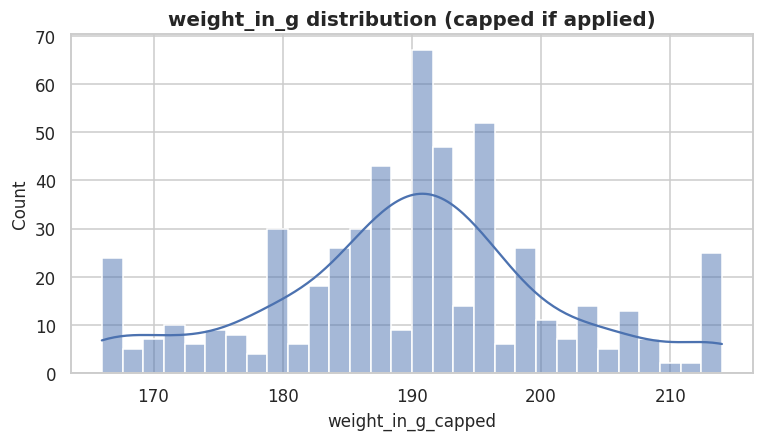

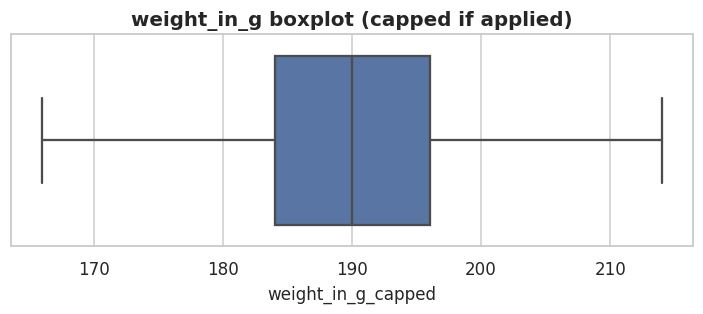

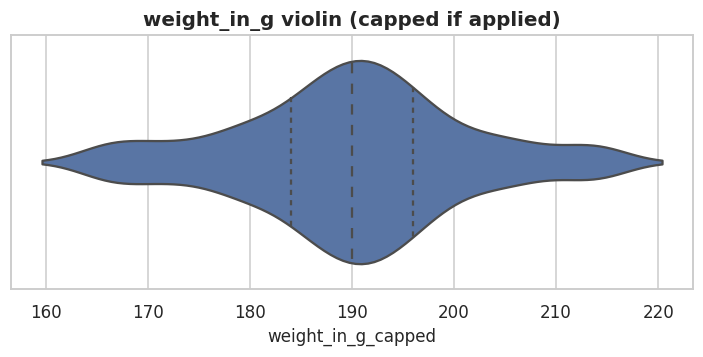


----- 5G_Band -----
Count non-null: 533
Mean: 0.31 Median: 0.0


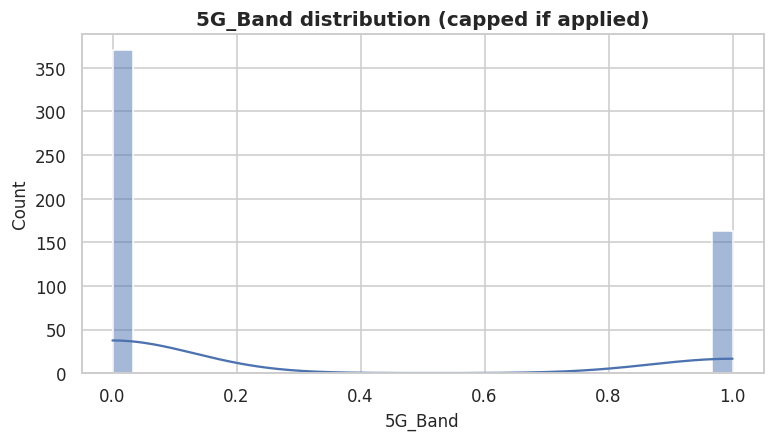

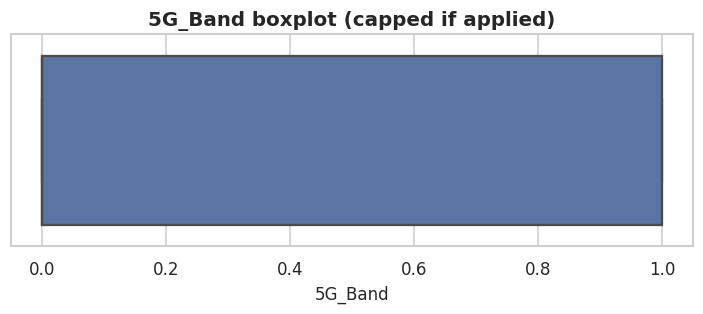

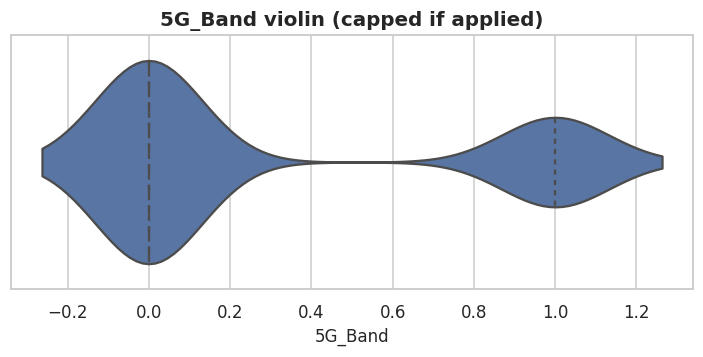


----- NFC -----
Count non-null: 533
Mean: 0.51 Median: 1.0


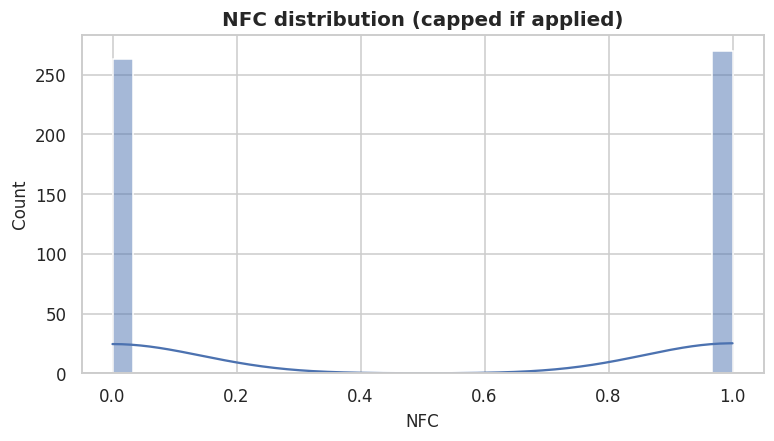

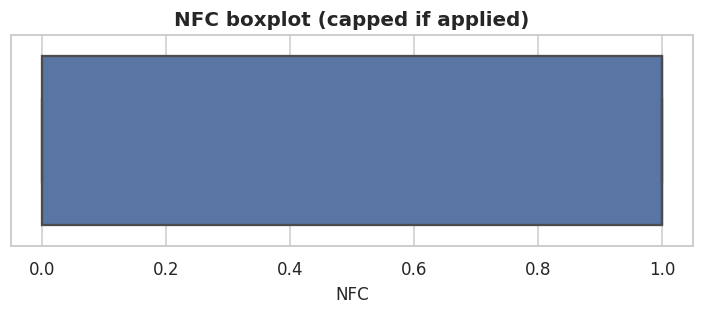

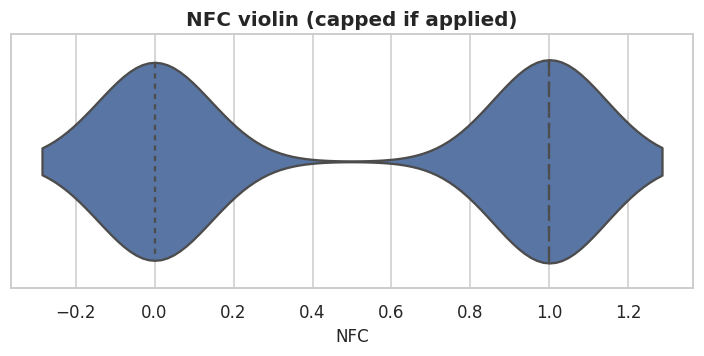


----- Amoled_display -----
Count non-null: 533
Mean: 0.48 Median: 0.0


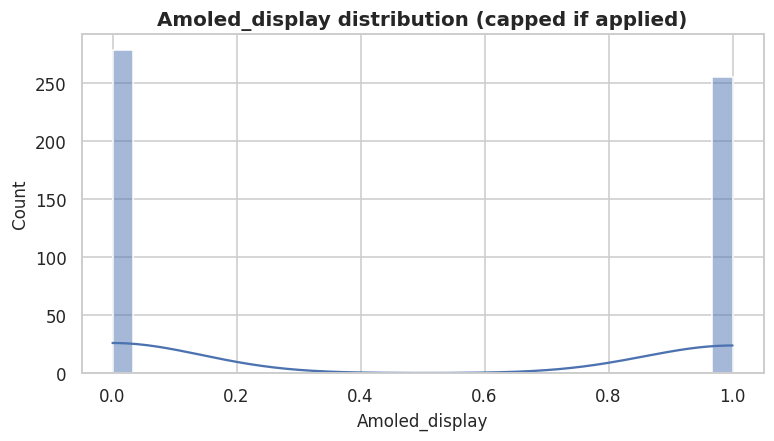

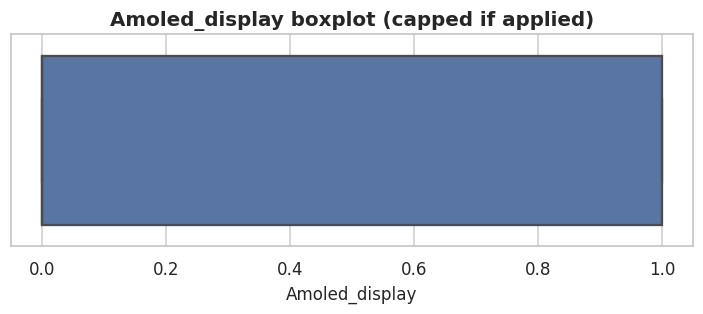

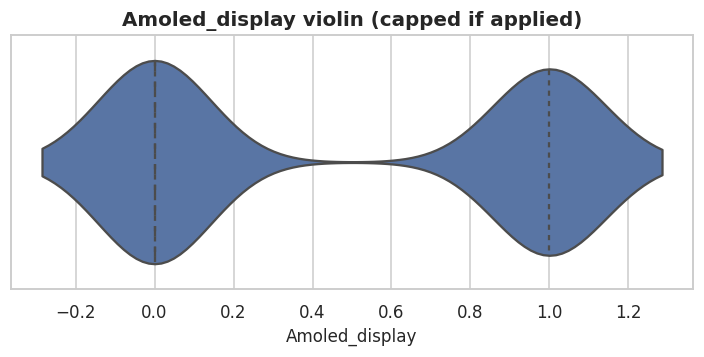


----- refresh_rate_hz -----
Count non-null: 533
Mean: 90.51 Median: 90.0


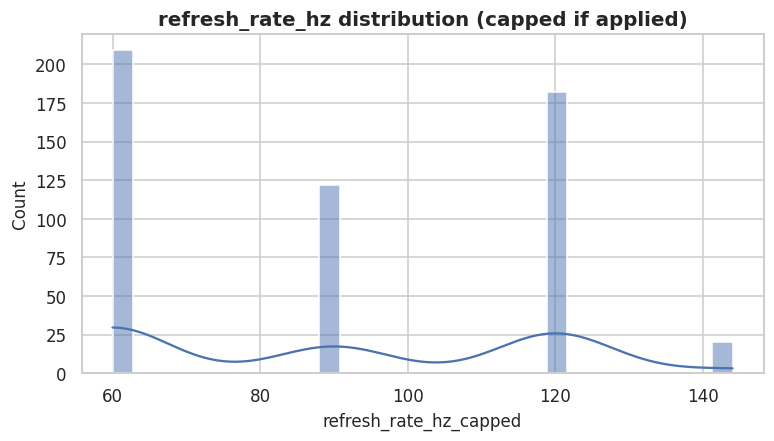

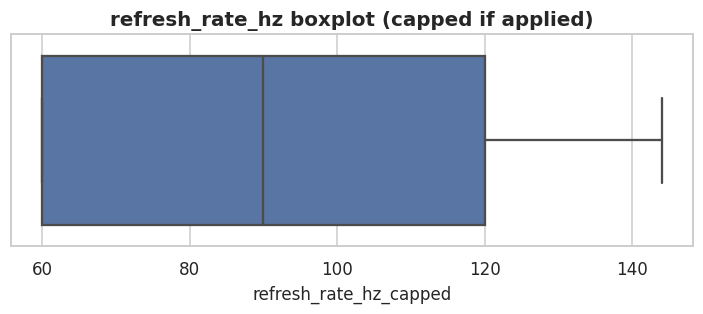

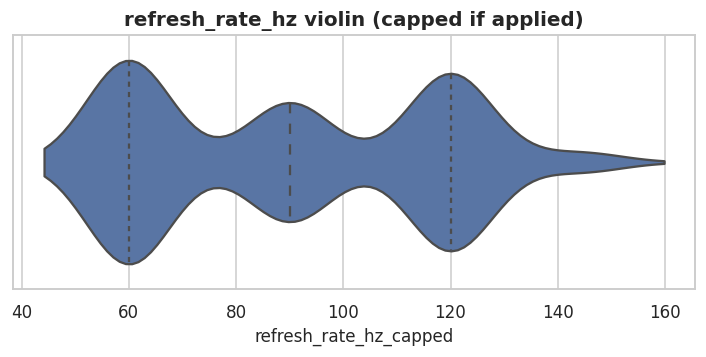


----- storage_gb -----
Count non-null: 533
Mean: 176.72 Median: 128.0


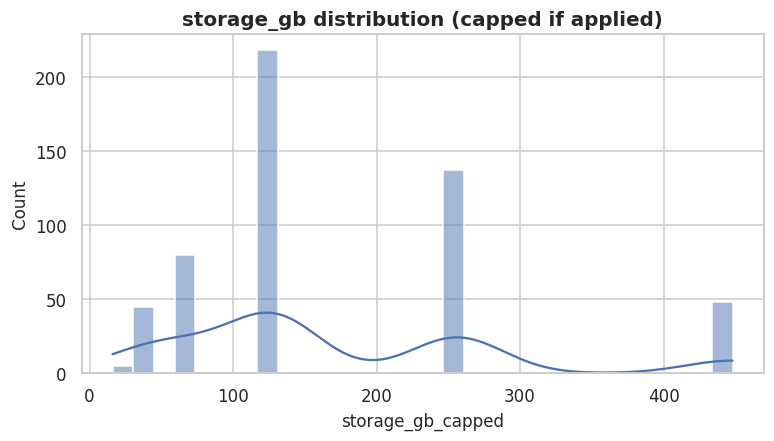

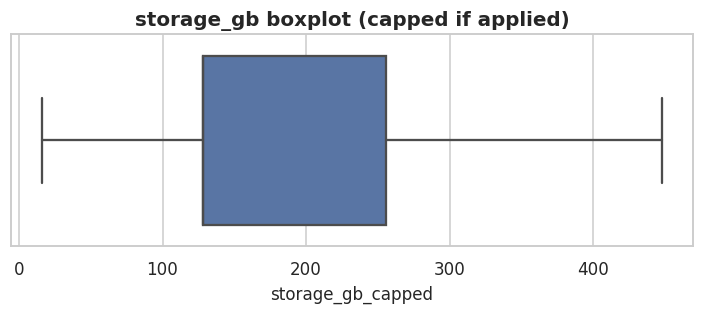

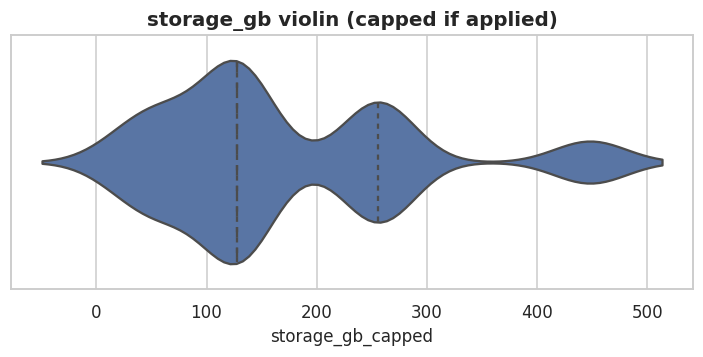


----- ram_gb -----
Count non-null: 533
Mean: 7.04 Median: 8.0


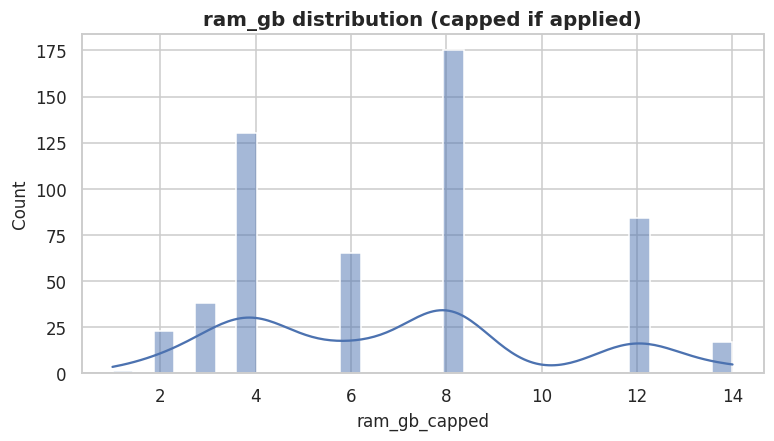

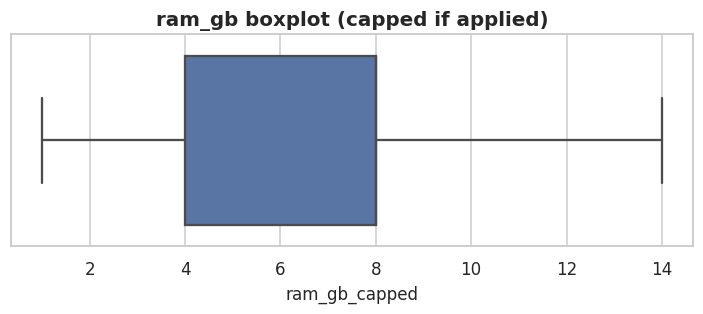

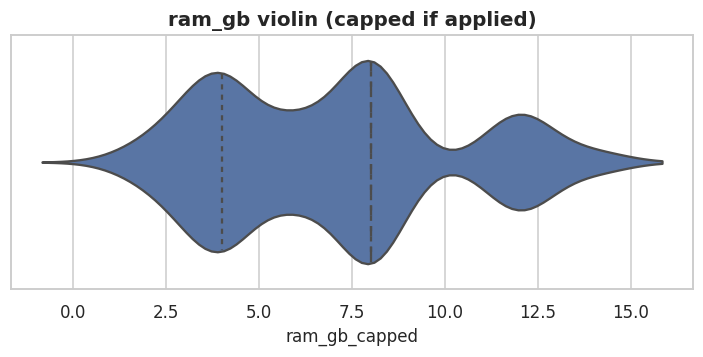


----- main_camera_max_MP -----
Count non-null: 533
Mean: 47.96 Median: 50.0


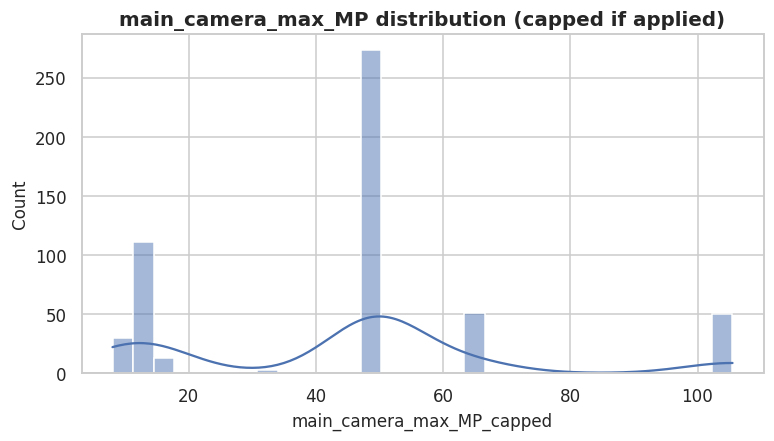

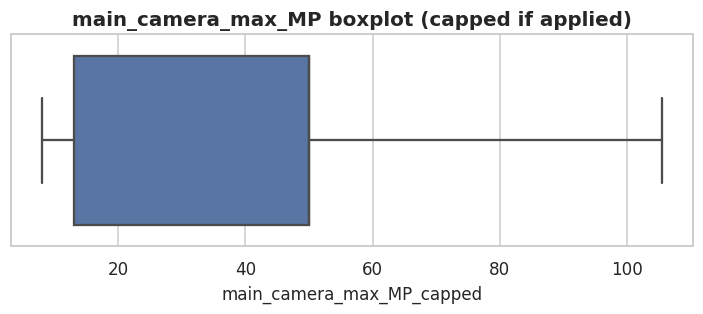

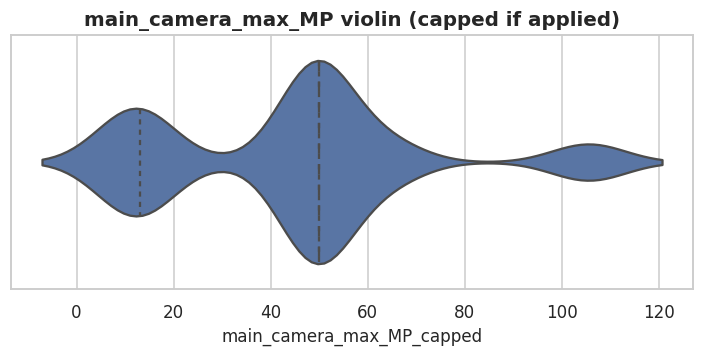


----- 4K_or_More_supportive -----
Count non-null: 533
Mean: 0.33 Median: 0.0


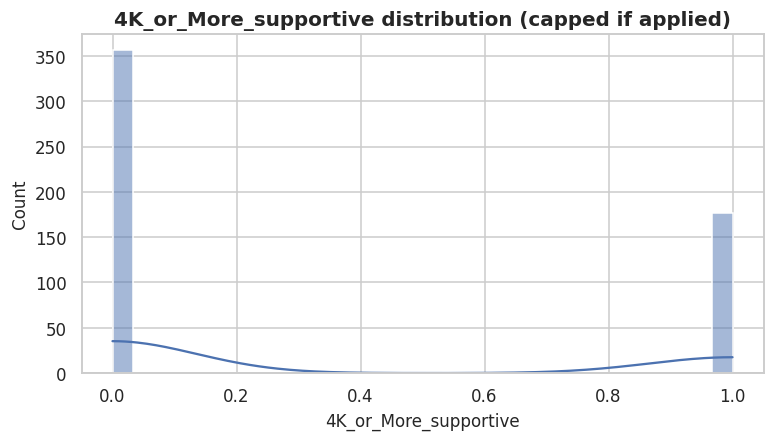

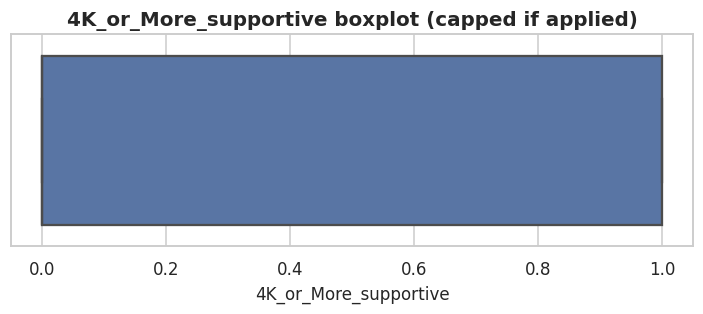

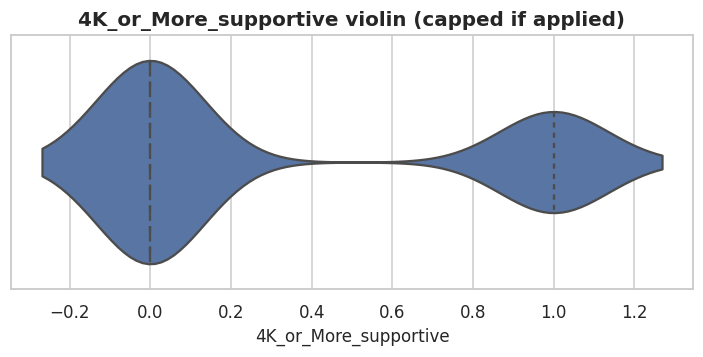


----- front_camer_max_MP -----
Count non-null: 533
Mean: 16.85 Median: 13.0


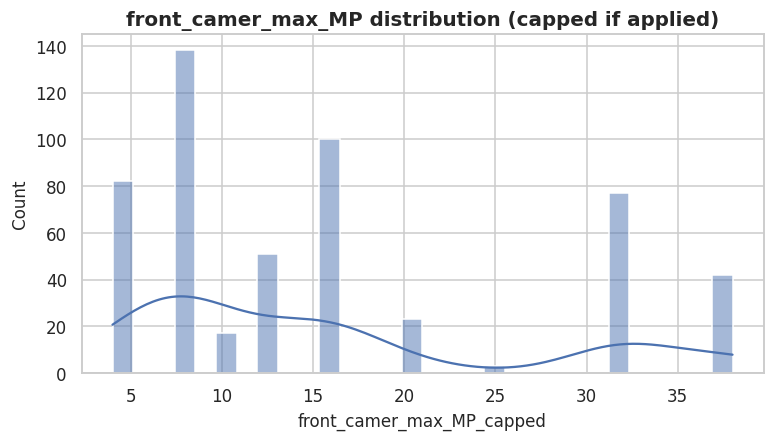

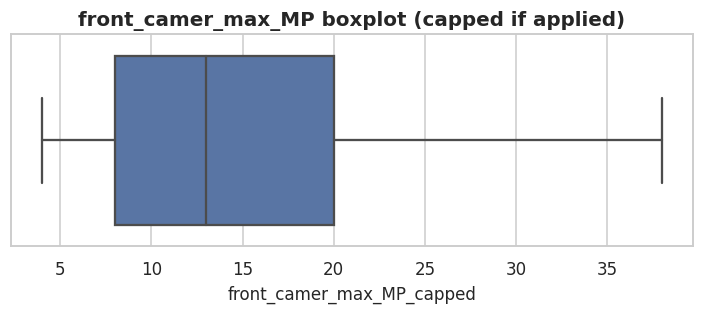

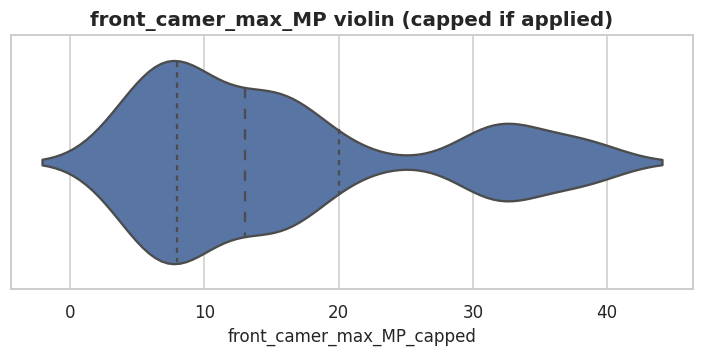


----- Type_C_supportive -----
Count non-null: 533
Mean: 0.8 Median: 1.0


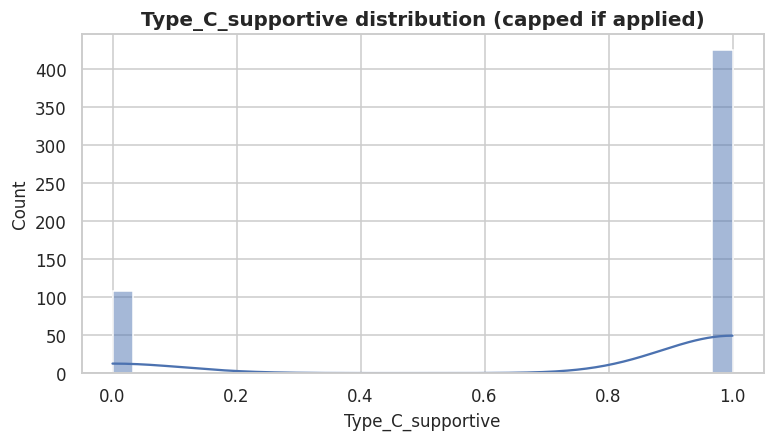

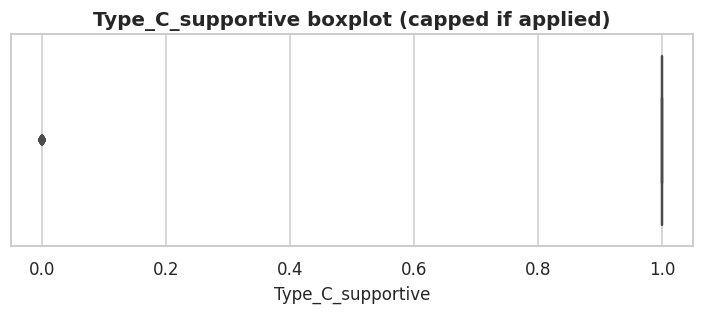

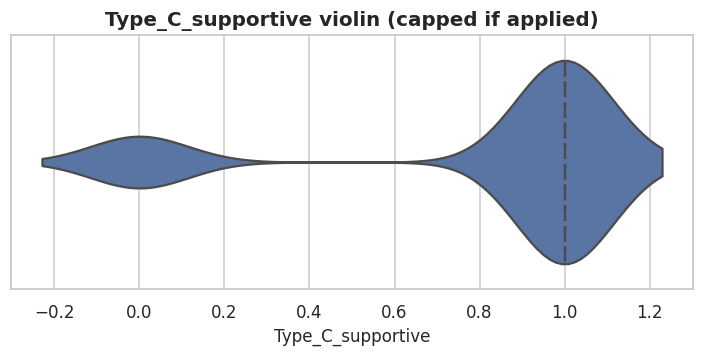


----- battery_mAh -----
Count non-null: 533
Mean: 4982.05 Median: 5000.0


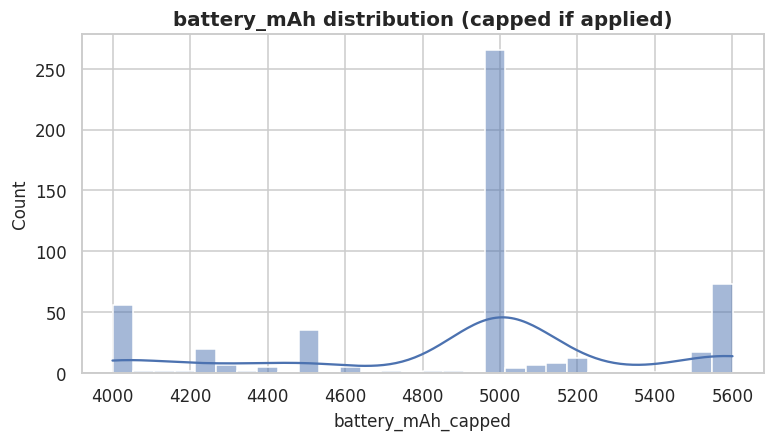

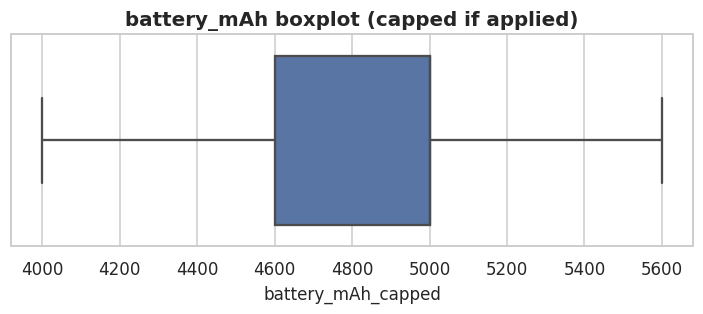

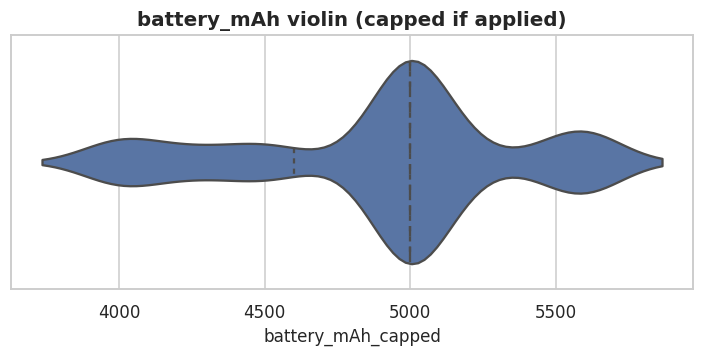


----- Price_PKR_capped -----
Count non-null: 533
Mean: 70630.02 Median: 49999.0


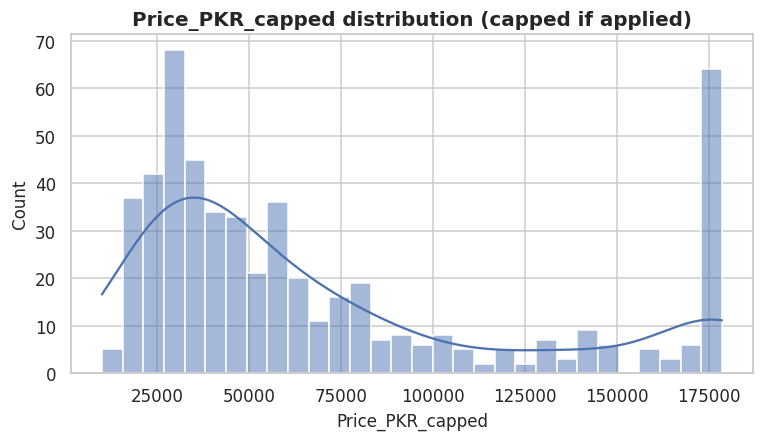

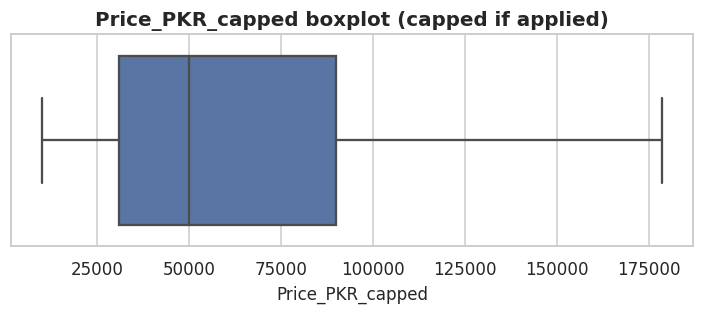

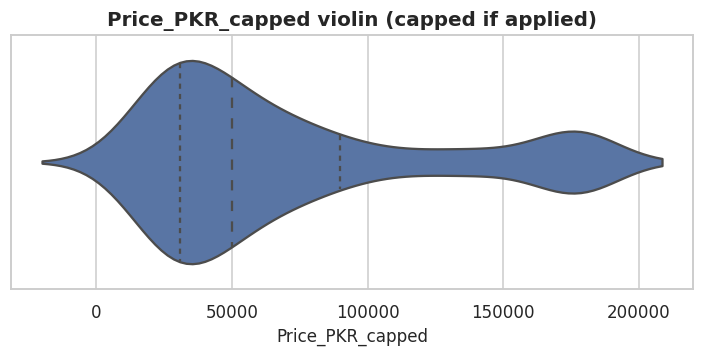


----- weight_in_g_capped -----
Count non-null: 533
Mean: 189.92 Median: 190.0


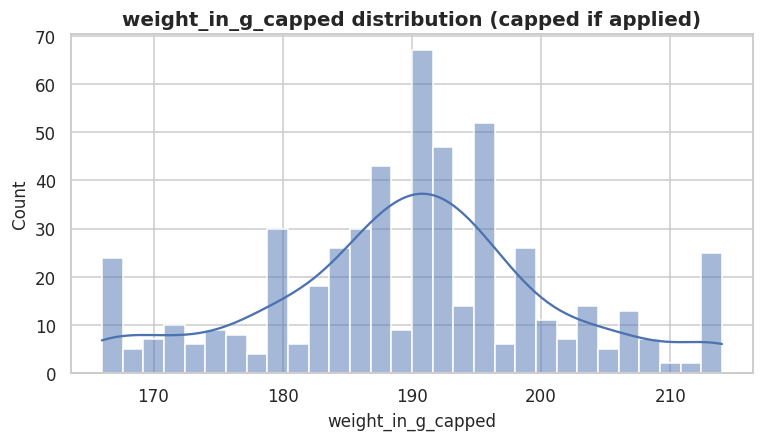

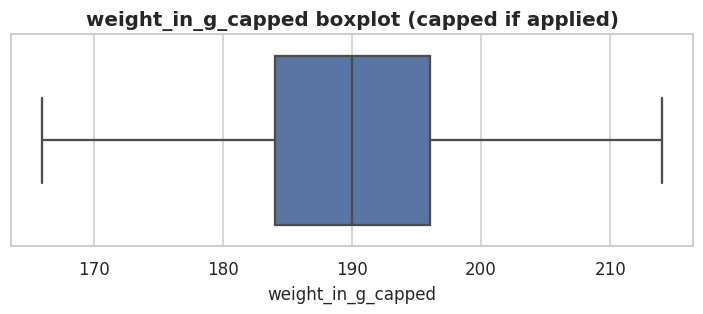

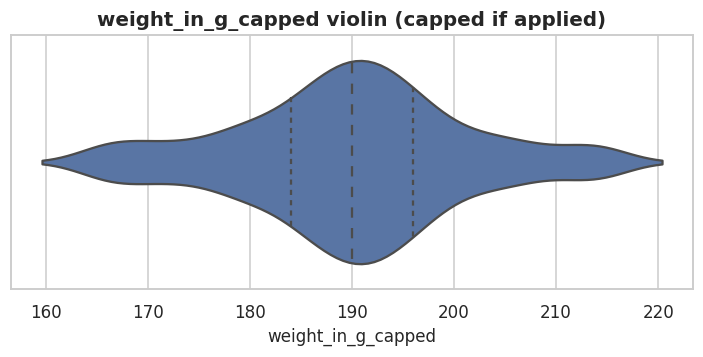


----- refresh_rate_hz_capped -----
Count non-null: 533
Mean: 90.51 Median: 90.0


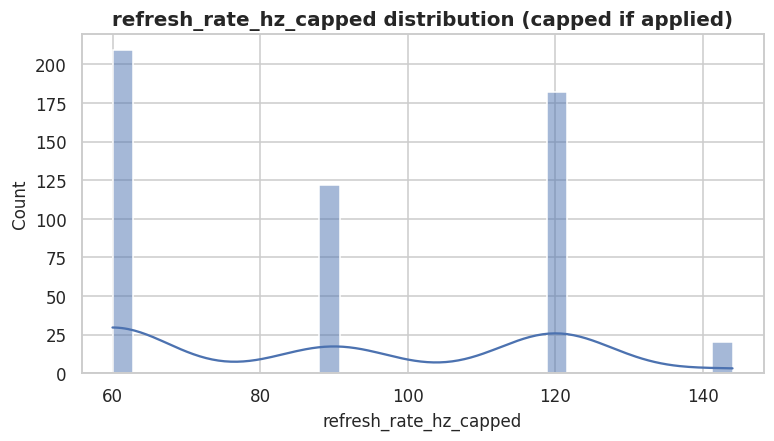

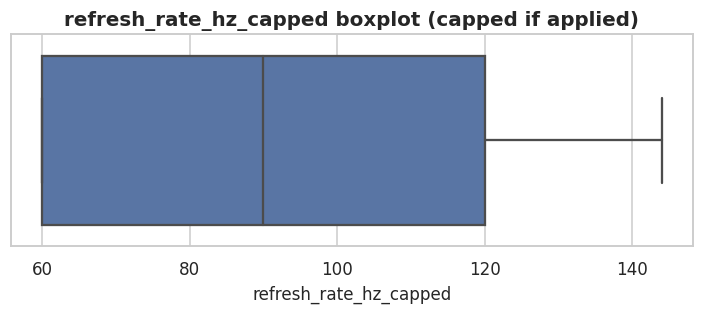

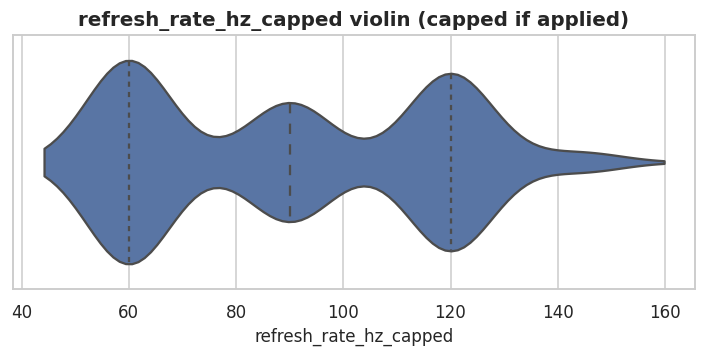


----- storage_gb_capped -----
Count non-null: 533
Mean: 170.96 Median: 128.0


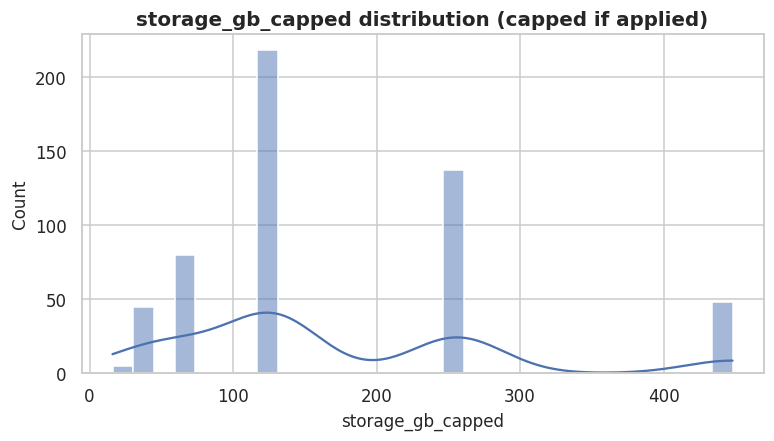

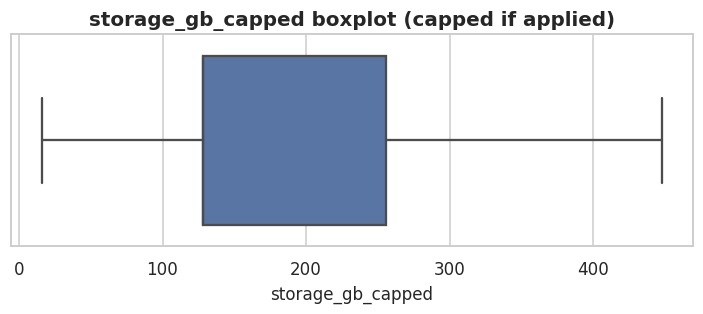

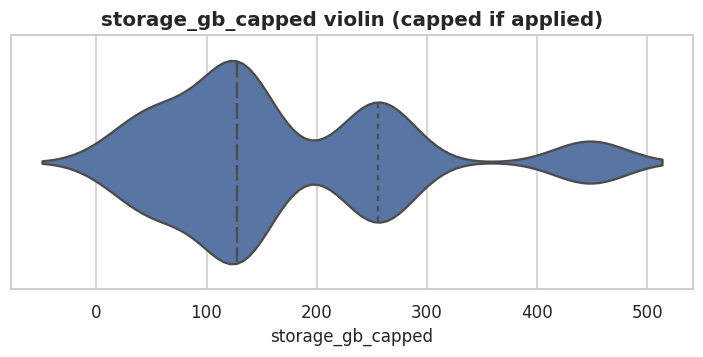


----- ram_gb_capped -----
Count non-null: 533
Mean: 6.97 Median: 8.0


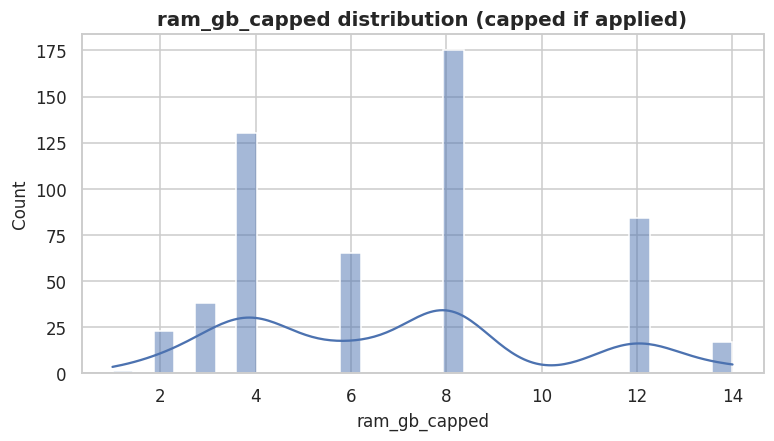

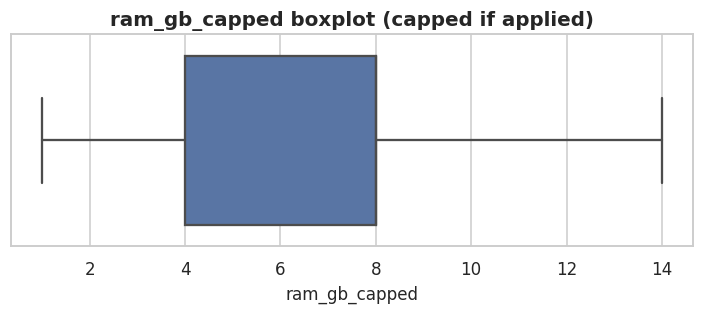

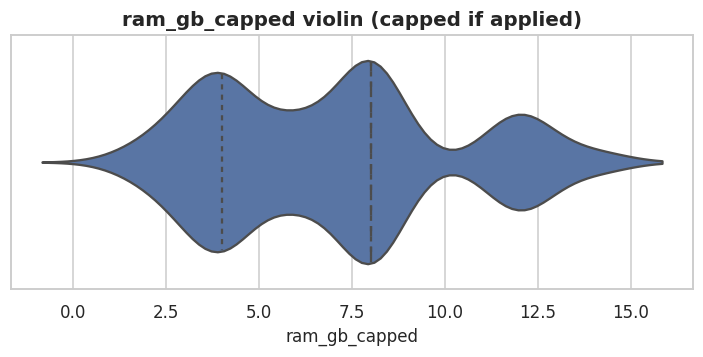


----- main_camera_max_MP_capped -----
Count non-null: 533
Mean: 45.14 Median: 50.0


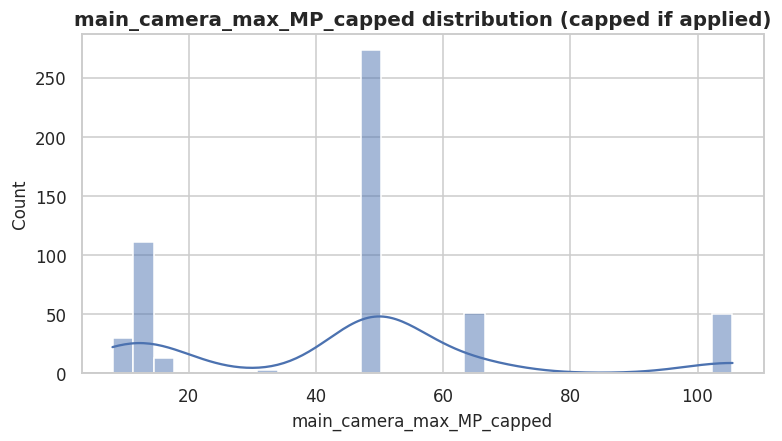

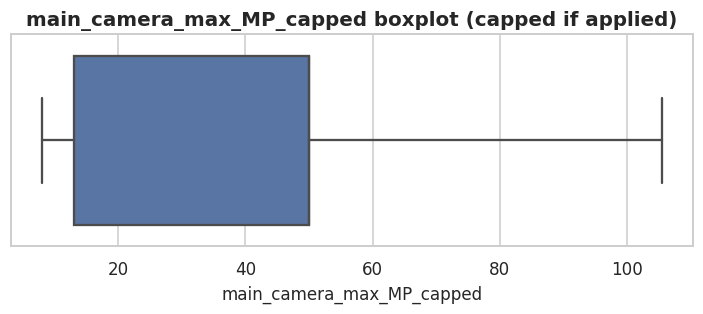

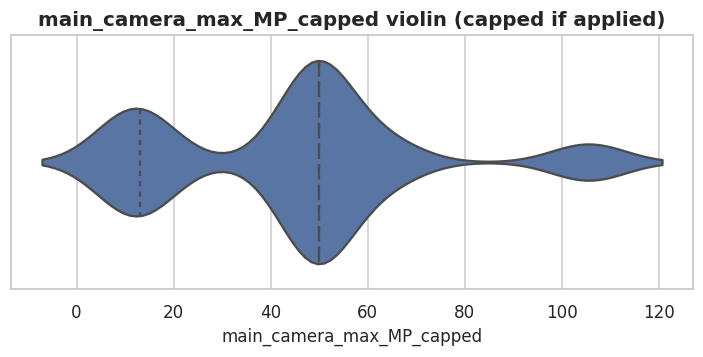


----- front_camer_max_MP_capped -----
Count non-null: 533
Mean: 16.0 Median: 13.0


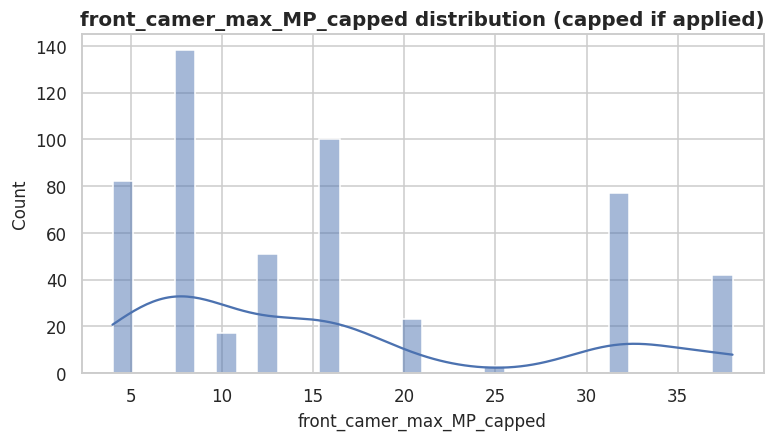

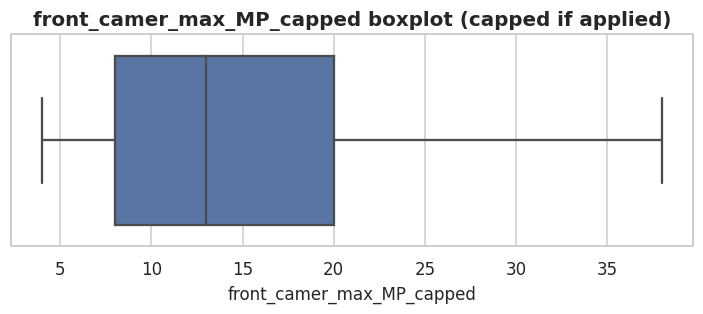

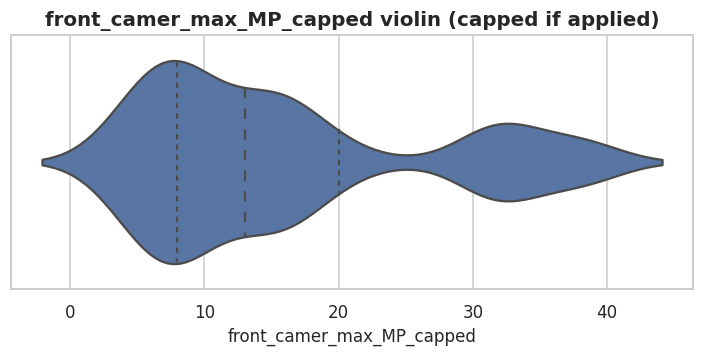


----- battery_mAh_capped -----
Count non-null: 533
Mean: 4907.93 Median: 5000.0


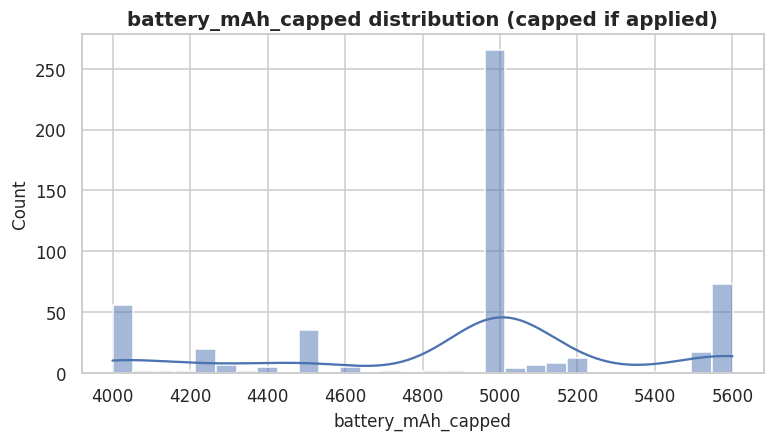

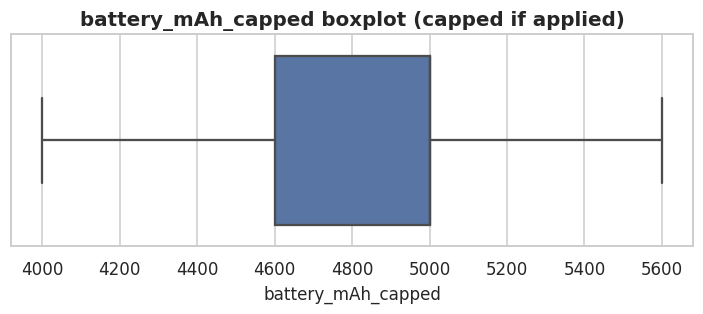

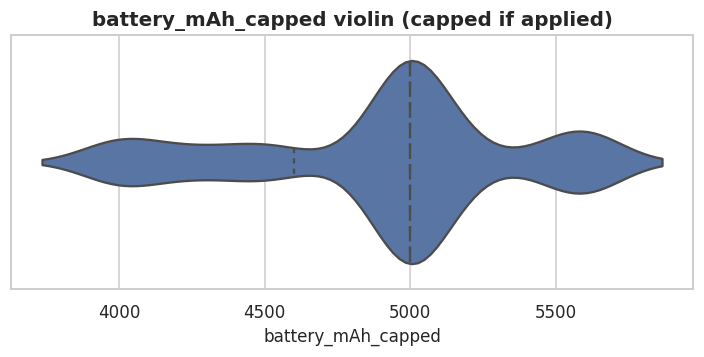

In [16]:

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove id-like or derived columns if present (example)
numeric_cols = [c for c in numeric_cols if c not in ['index','Unnamed: 0']]

print("Numeric columns to analyze:", numeric_cols)

# 8.1 — price summary
if 'Price_PKR' in df.columns:
    price = df['Price_PKR']
    stats_price = {
        'mean': price.mean(), 'median': price.median(), 'std': price.std(),
        'min': price.min(), 'max': price.max(), 'skew': stats.skew(price.dropna()), 'kurtosis': stats.kurtosis(price.dropna())
    }
    print("Price stats:", {k: (round(v,2) if isinstance(v,(int,float)) else v) for k,v in stats_price.items()})
    show_hist_kde(df['Price_PKR_capped'] if 'Price_PKR_capped' in df.columns else df['Price_PKR'], title="Price (PKR) distribution (capped)")

# 8.2 — loop through numeric variables and plot hist, box and violin
for col in numeric_cols:
    if col == 'Price_PKR': continue
    capped = col + '_capped' if (col + '_capped') in df.columns else col
    print("\n-----", col, "-----")
    print("Count non-null:", int(df[col].notna().sum()))
    print("Mean:", round(df[col].mean(skipna=True),2), "Median:", round(df[col].median(skipna=True),2))
    show_hist_kde(df[capped], title=f"{col} distribution (capped if applied)")
    show_box(df[capped], title=f"{col} boxplot (capped if applied)")
    # violin for clarity if not too many distinct values
    try:
        show_violin(df[capped], title=f"{col} violin (capped if applied)")
    except Exception as e:
        print("Violin skipped for", col, ":", e)


# Explanation
Thorough univariate analysis of numeric columns: statistics + histogram + boxplot + violin. We use capped values where available to reduce outlier-driven plots.

# UNIVARIATE ANALYSIS (CATEGORICAL)

Categorical columns: ['Category', 'Model_Title', 'UI', 'Brand', 'gpu_category', 'price_range']

=== Column: Category ===


Category
Available      503
Coming Soon     30
Name: count, dtype: int64

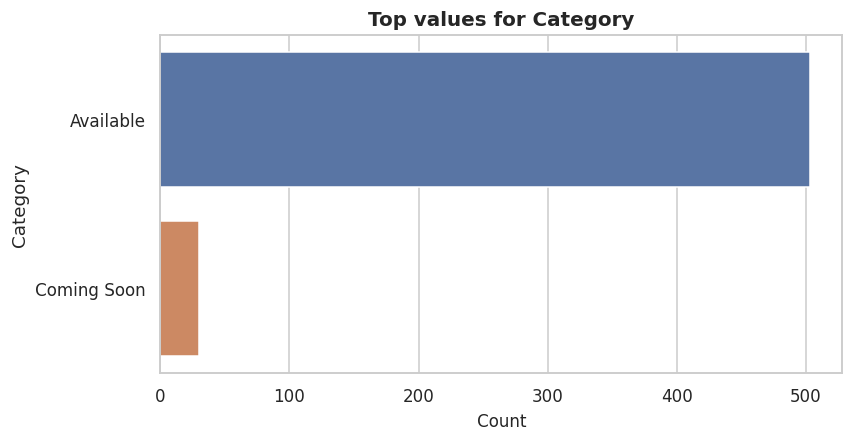

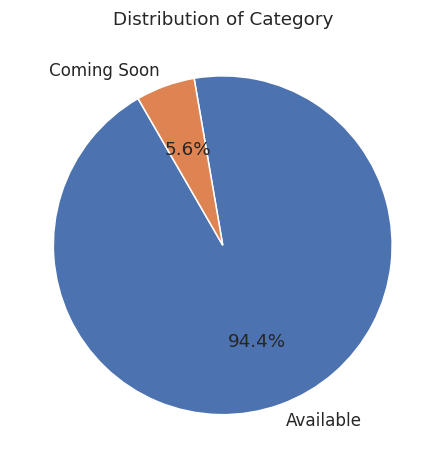


=== Column: Model_Title ===


Model_Title
Infinix Zero Flip           1
Xiaomi Redmi 15C            1
Xiaomi Redmi 12C 128GB      1
Xiaomi Redmi Note 12 8GB    1
Xiaomi 13T                  1
Xiaomi 13T Pro              1
Xiaomi Mix Flip             1
Xiaomi Redmi A3x            1
Xiaomi Redmi A5             1
Xiaomi Redmi A3             1
Name: count, dtype: int64

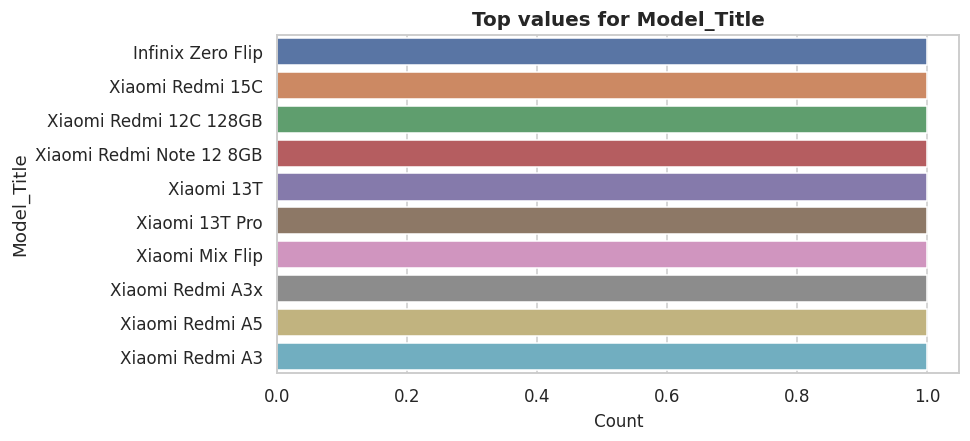


=== Column: UI ===


UI
OneUI       103
XOS         101
Funtouch     86
ColorOS      84
MIUI         68
HyperOS      31
OxygenOS     22
MIU          13
Color OS     11
One UI        4
Name: count, dtype: int64

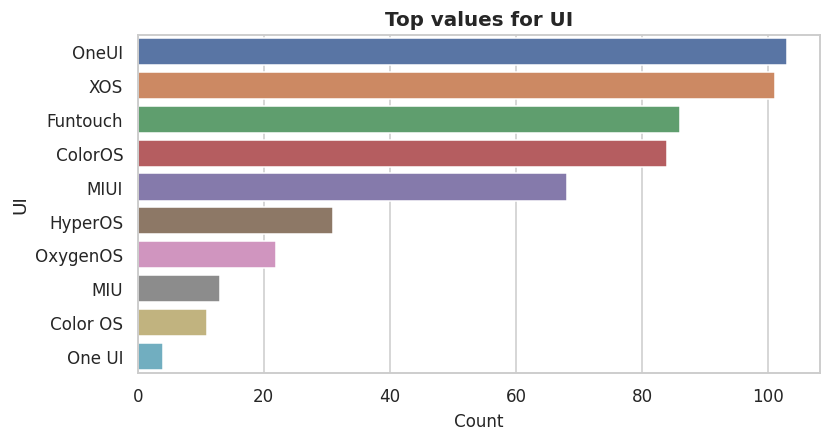


=== Column: Brand ===


Brand
Xiaomi     115
Samsung    107
Infinix    101
Oppo        96
Vivo        89
Oneplus     25
Name: count, dtype: int64

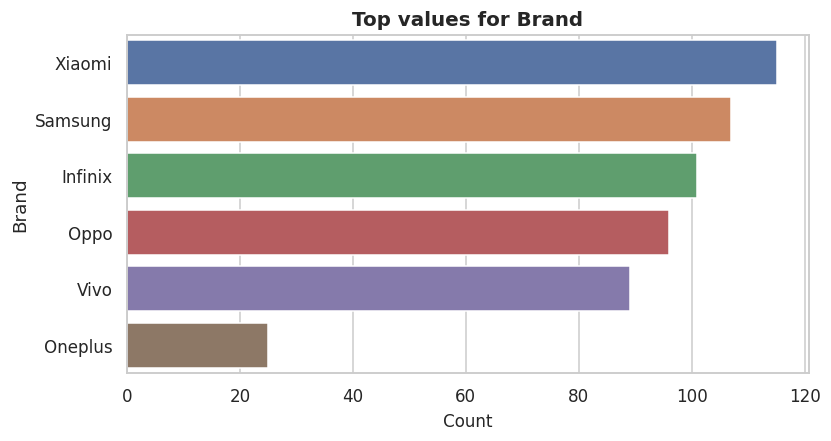

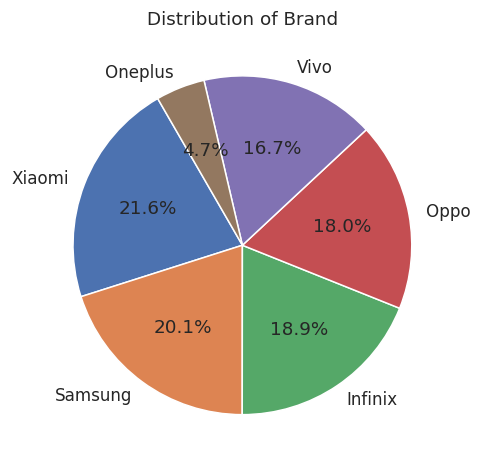


=== Column: gpu_category ===


gpu_category
Mali           241
Adreno         194
IMG/PowerVR     85
Xclipse          8
Immortalis       5
Name: count, dtype: int64

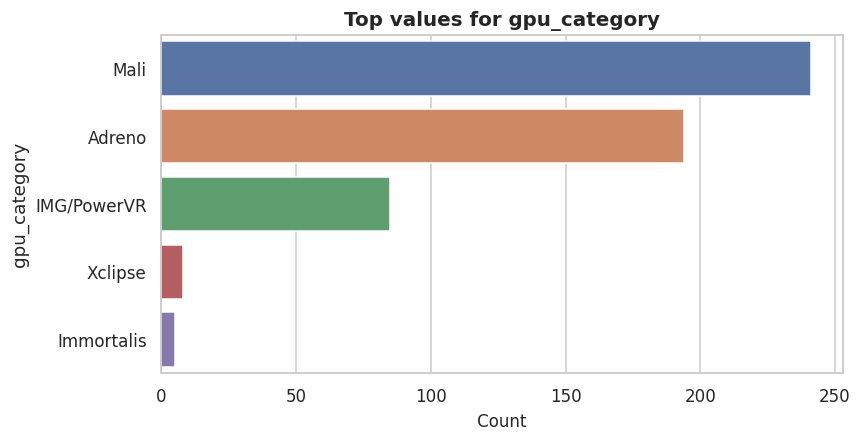

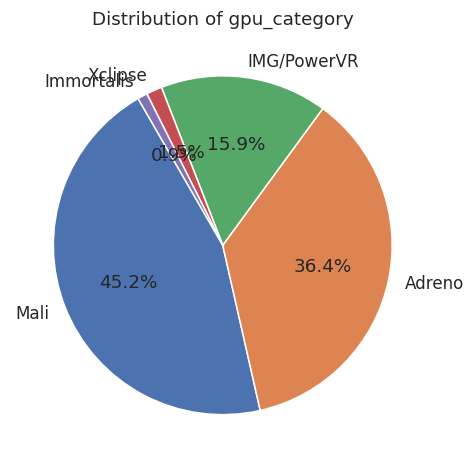


=== Column: price_range ===


price_range
Budget       138
Mid-Range    138
Premium      131
High-End     126
Name: count, dtype: int64

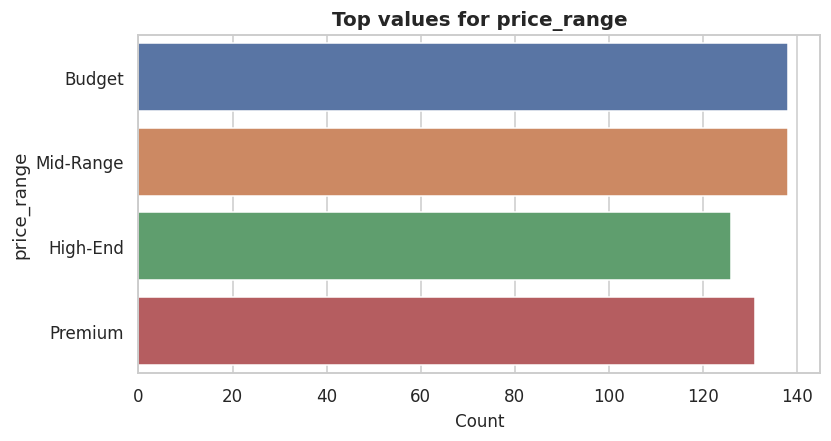

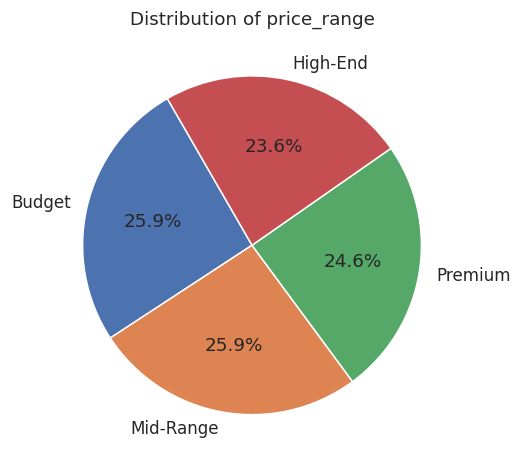

In [17]:
# --------------------------
# SECTION 9 — UNIVARIATE ANALYSIS (CATEGORICAL)
# --------------------------
cat_cols = df.select_dtypes(include='object').columns.tolist()
# include price_range as categorical if it's present
if 'price_range' in df.columns and 'price_range' not in cat_cols:
    cat_cols.append('price_range')

print("Categorical columns:", cat_cols)

for c in cat_cols:
    print("\n=== Column:", c, "===")
    vc = df[c].value_counts(dropna=False)
    display(vc.head(10))
    # barplot for top categories
    topn = vc.head(10)
    fig, ax = plt.subplots(figsize=(8,4))
    sns.barplot(x=topn.values, y=topn.index, ax=ax)
    set_labels(ax, xlabel='Count', title=f"Top values for {c}")
    plt.show()
    # if small number of unique values, show pie
    if vc.shape[0] <= 6:
        fig2, ax2 = plt.subplots(figsize=(5,5))
        ax2.pie(vc, labels=vc.index, autopct='%1.1f%%', startangle=120)
        ax2.set_title(f"Distribution of {c}")
        plt.show()


# Explanation
For each categorical column, display top counts and draw bar and (if small unique count) pie charts. This helps non-technical stakeholders quickly see dominant categories.

# BIVARIATE: NUMERIC vs PRICE

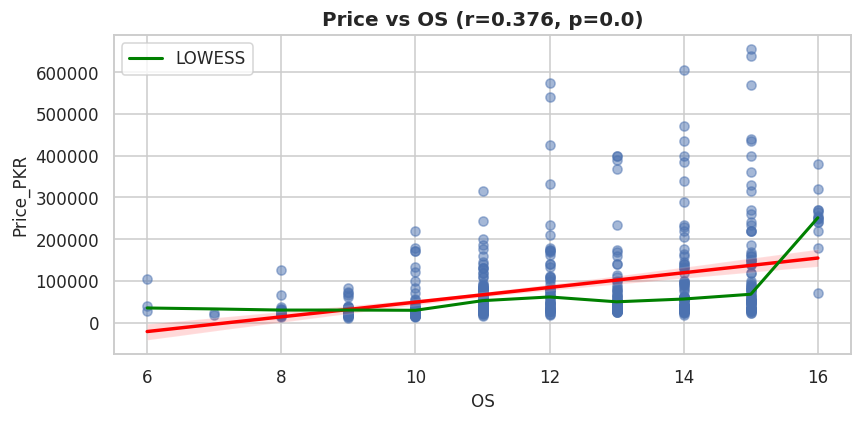

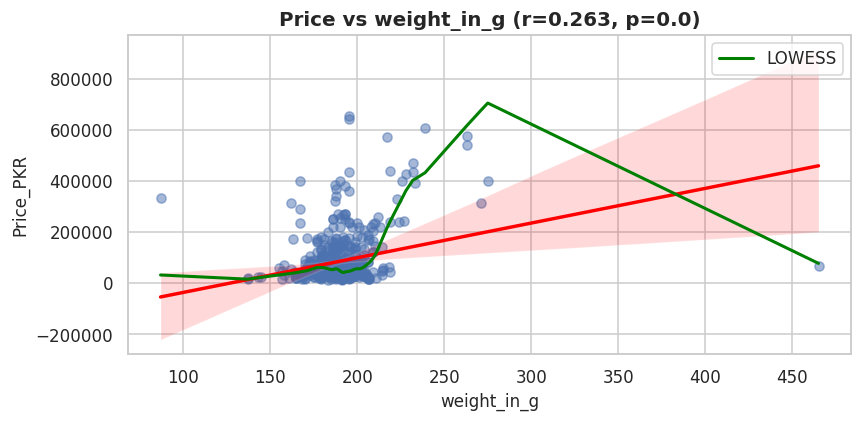

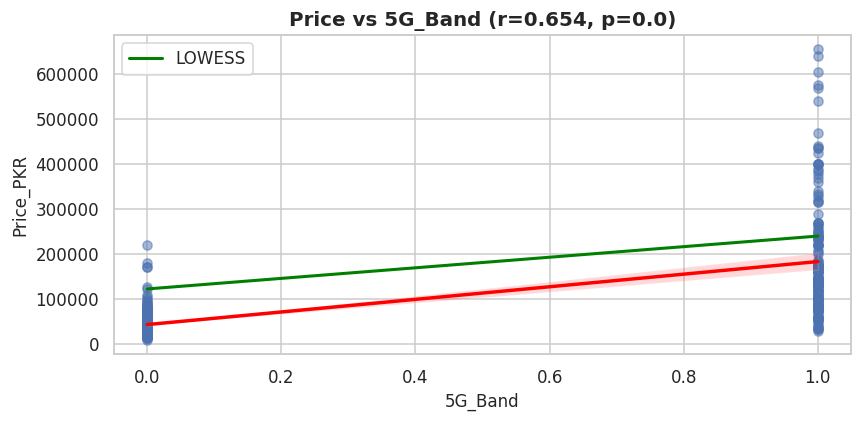

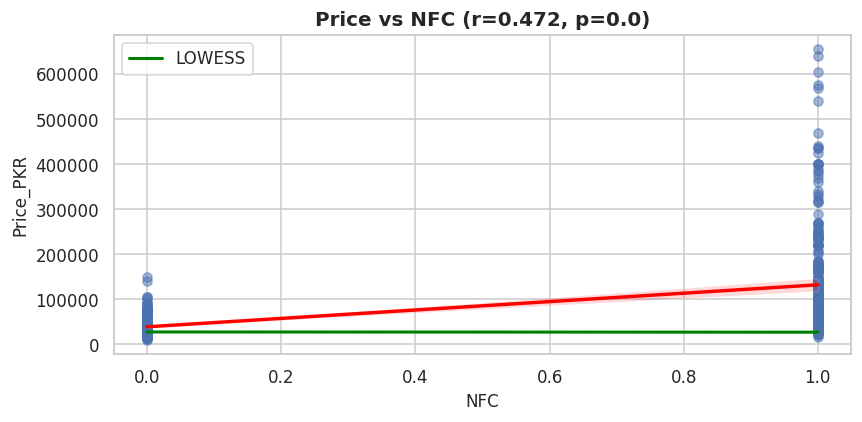

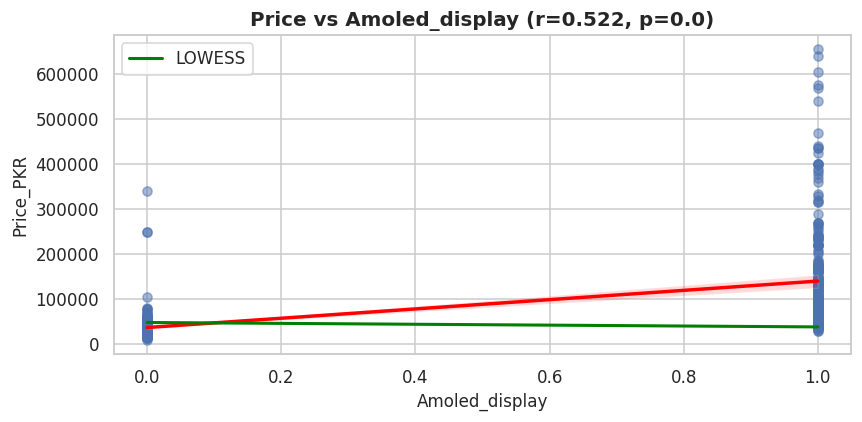

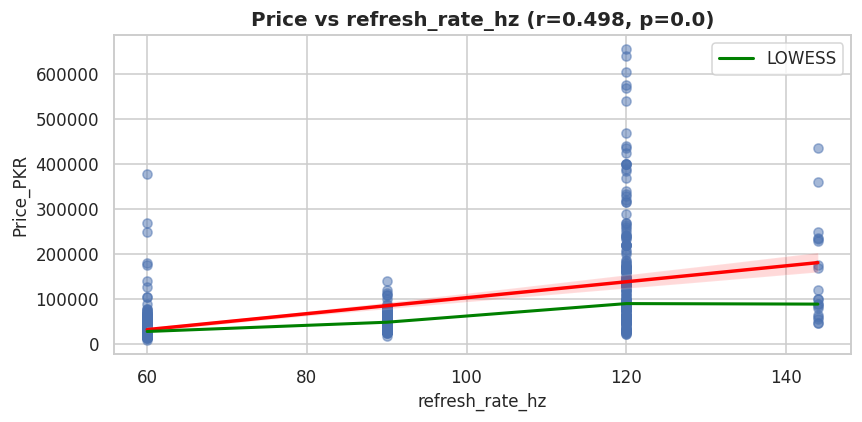

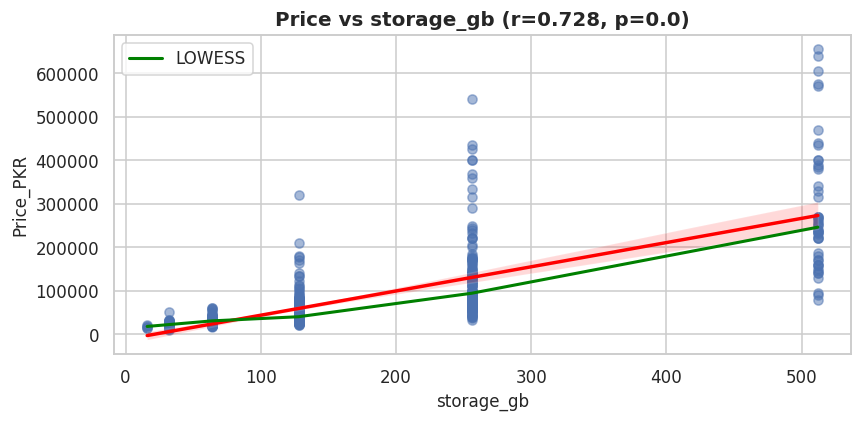

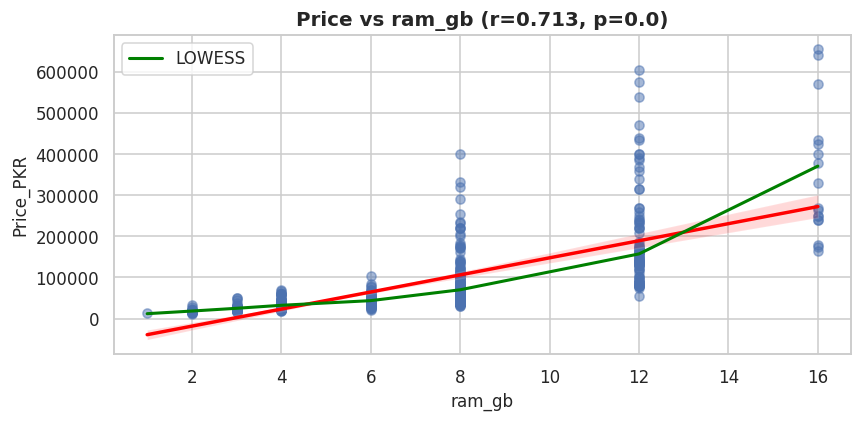

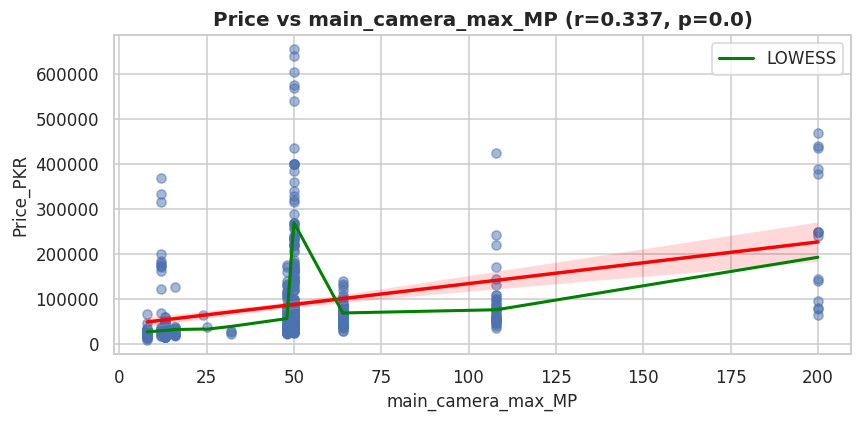

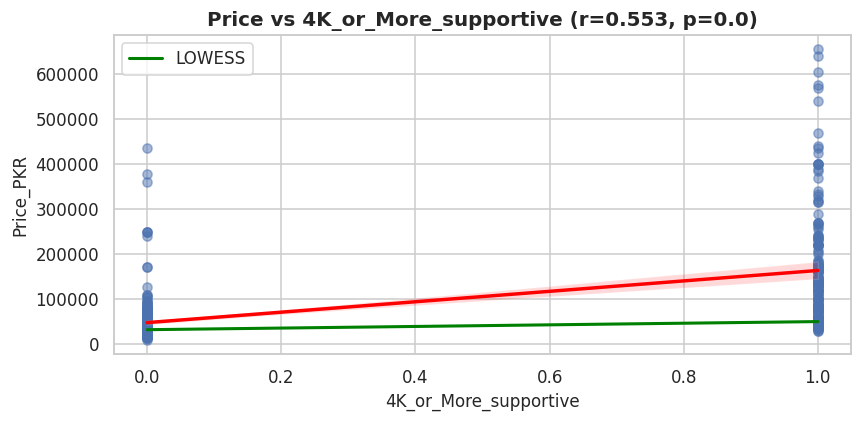

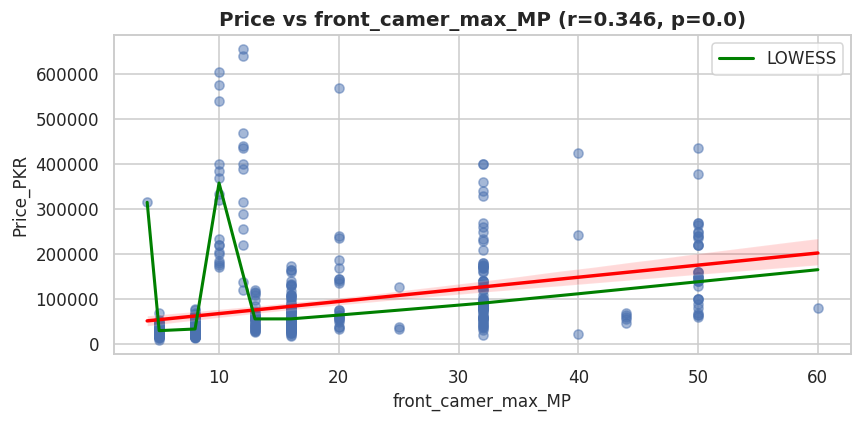

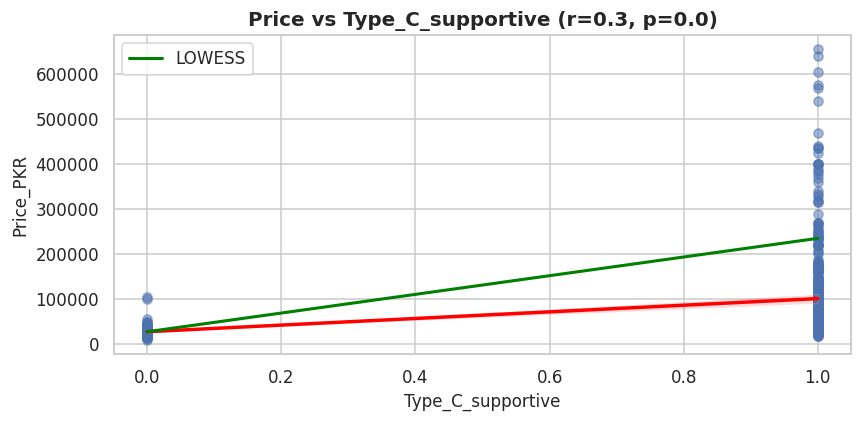

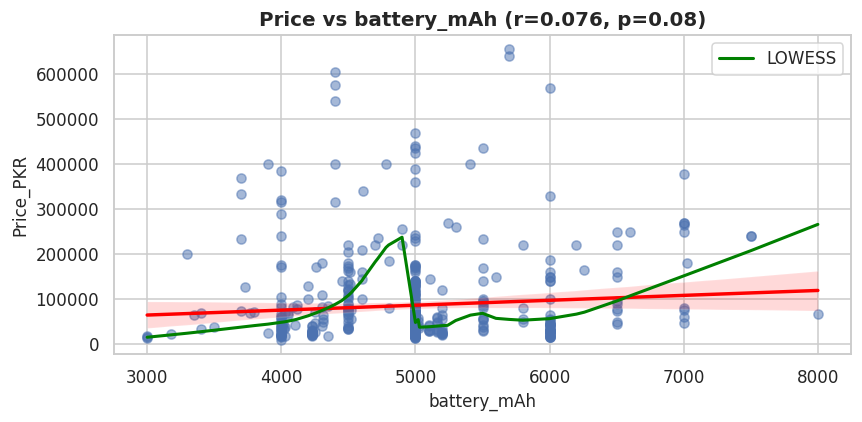

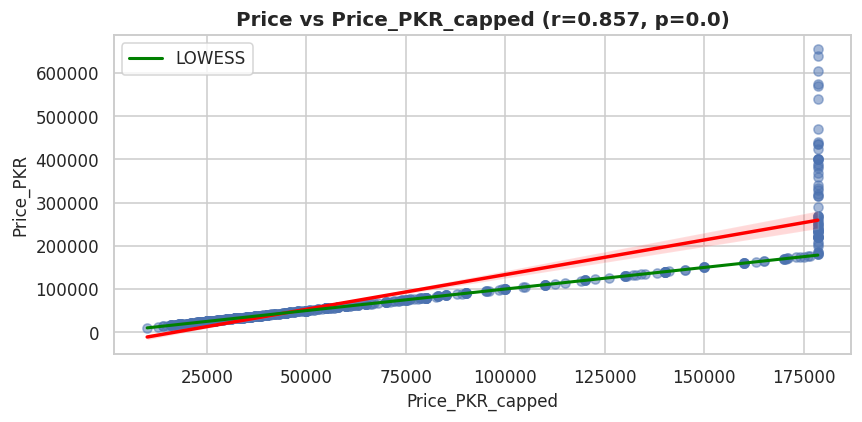

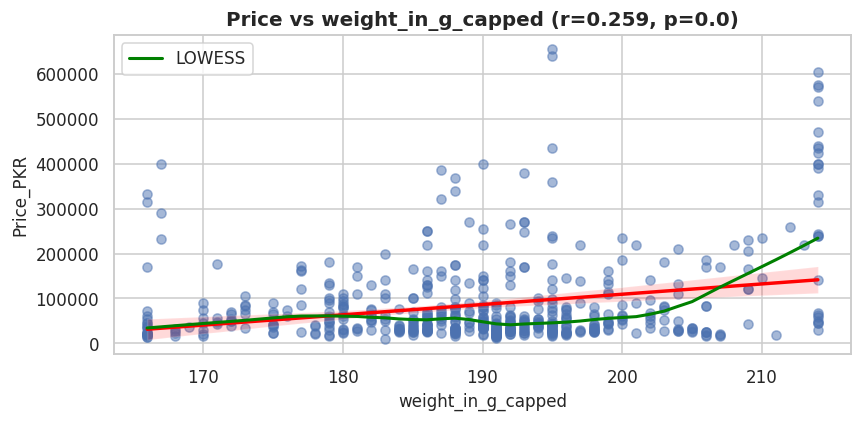

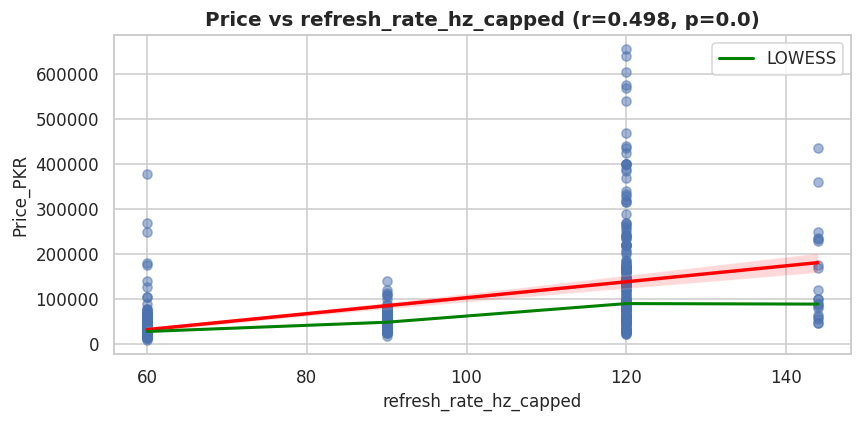

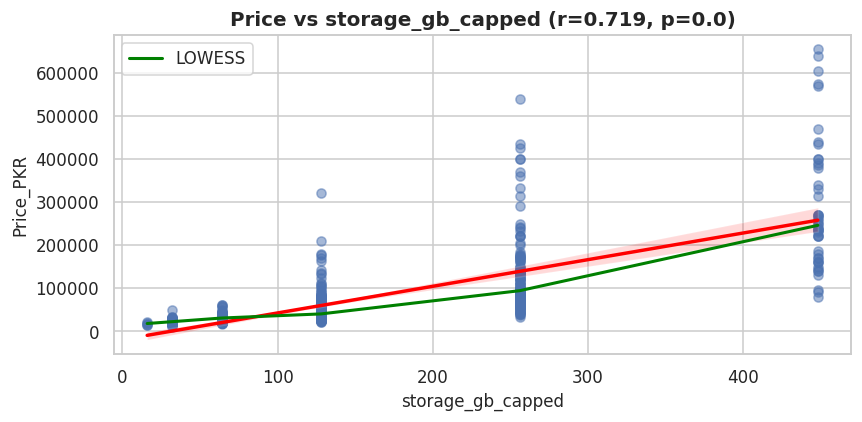

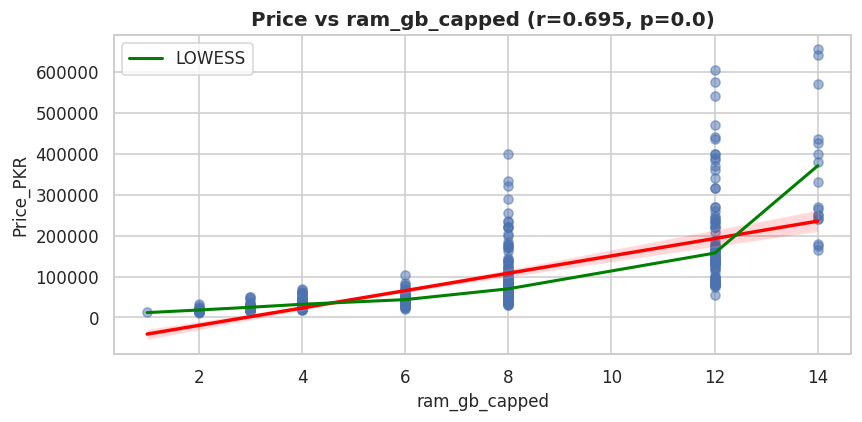

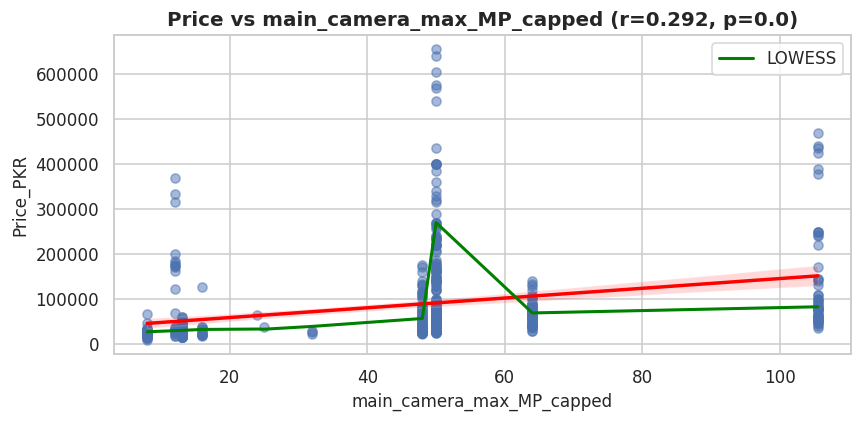

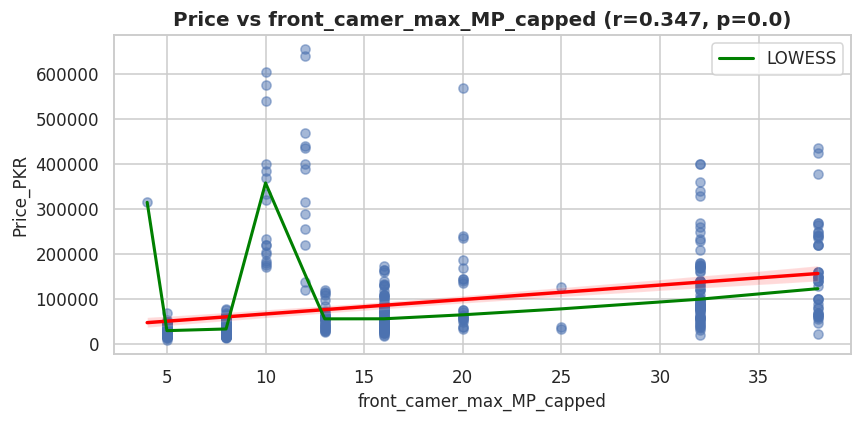

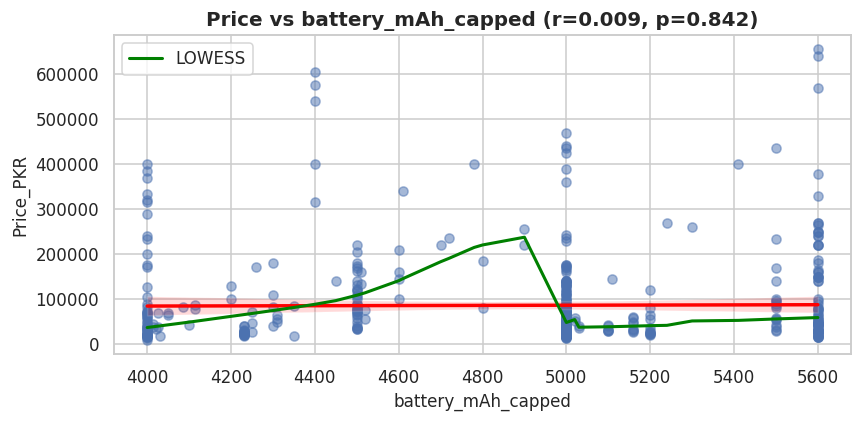

,feature,pearson_r,p_value,n
0,Price_PKR_capped,0.857082,4.533836e-155,533
1,storage_gb,0.727532,6.160693e-89,533
2,storage_gb_capped,0.718573,8.424114e-86,533
3,ram_gb,0.712624,8.740508e-84,533
4,ram_gb_capped,0.694806,4.815928e-78,533
5,5G_Band,0.653910,2.466400e-66,533
6,4K_or_More_supportive,0.552871,5.384077e-44,533
7,Amoled_display,0.522451,1.157460e-38,533
8,refresh_rate_hz,0.498109,9.077635e-35,533
9,refresh_rate_hz_capped,0.498109,9.077635e-35,533


In [18]:
# --------------------------
# BIVARIATE: NUMERIC vs PRICE (scatter/reg + LOWESS)
# --------------------------
num_for_bi = [c for c in numeric_cols if c != 'Price_PKR' and c in df.columns]

bivar_results = []

for c in num_for_bi:
    clean = df[[c, 'Price_PKR']].dropna()
    if len(clean) < 10:
        continue

    x = clean[c].values
    y = clean['Price_PKR'].values

    # Pearson correlation
    try:
        r, p = pearsonr(x, y)
    except Exception:
        r, p = (np.nan, np.nan)

    # Save results
    bivar_results.append({
        'feature': c,
        'pearson_r': r,
        'p_value': p,
        'n': len(clean)
    })

    # scatter + regression line
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.regplot(
        x=c, y='Price_PKR',
        data=clean,
        scatter_kws={'alpha': 0.5},
        ax=ax,
        line_kws={'color': 'red'}
    )

    # LOWESS smoothing
    try:
        lo = lowess(y, x, frac=0.3)
        ax.plot(lo[:, 0], lo[:, 1], color='green', linewidth=2, label='LOWESS')
    except Exception:
        pass

    # PREPARE TITLE SAFELY
    r_val = round(r, 3) if not np.isnan(r) else "NA"
    p_val = round(p, 3) if not np.isnan(p) else "NA"

    set_labels(
        ax,
        xlabel=c,
        ylabel='Price_PKR',
        title=f'Price vs {c} (r={r_val}, p={p_val})'
    )

    ax.legend()
    plt.tight_layout()
    plt.show()

pd.DataFrame(bivar_results).sort_values(
    by='pearson_r', ascending=False
).reset_index(drop=True)


#  BIVARIATE: CATEGORICAL vs PRICE

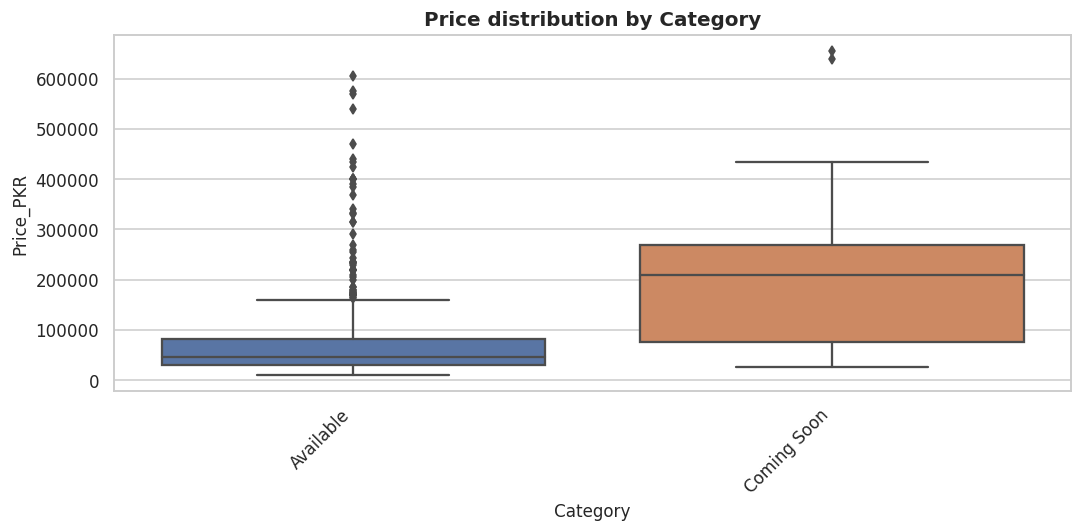

ANOVA for Category: F = 59.372; p = 0.0
Skipping Model_Title (too many categories: 533)


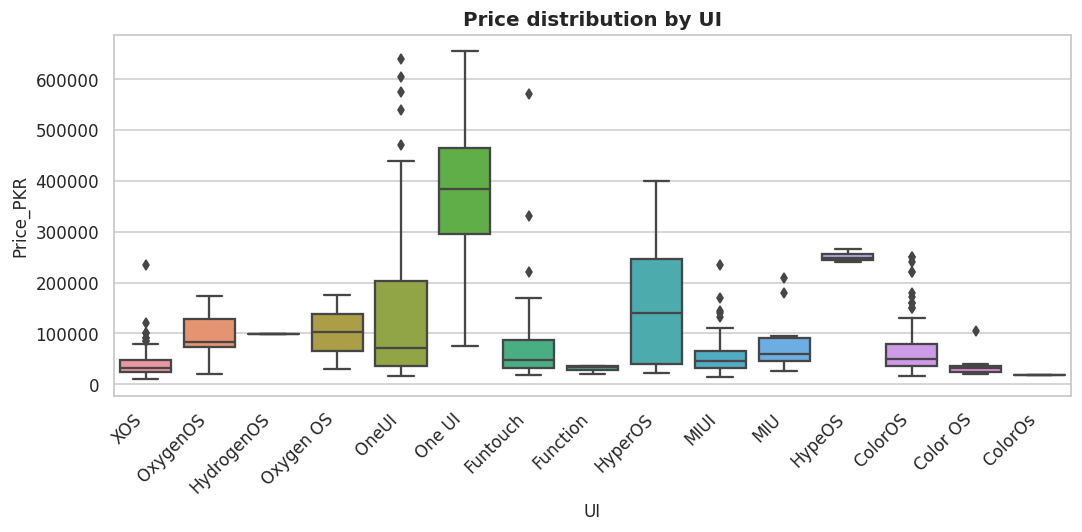

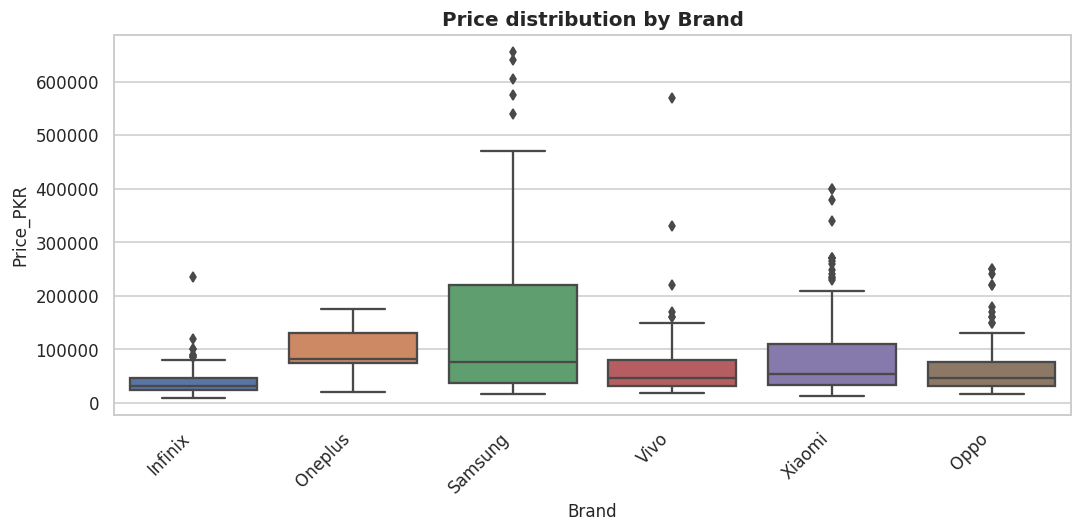

ANOVA for Brand: F = 17.568; p = 0.0


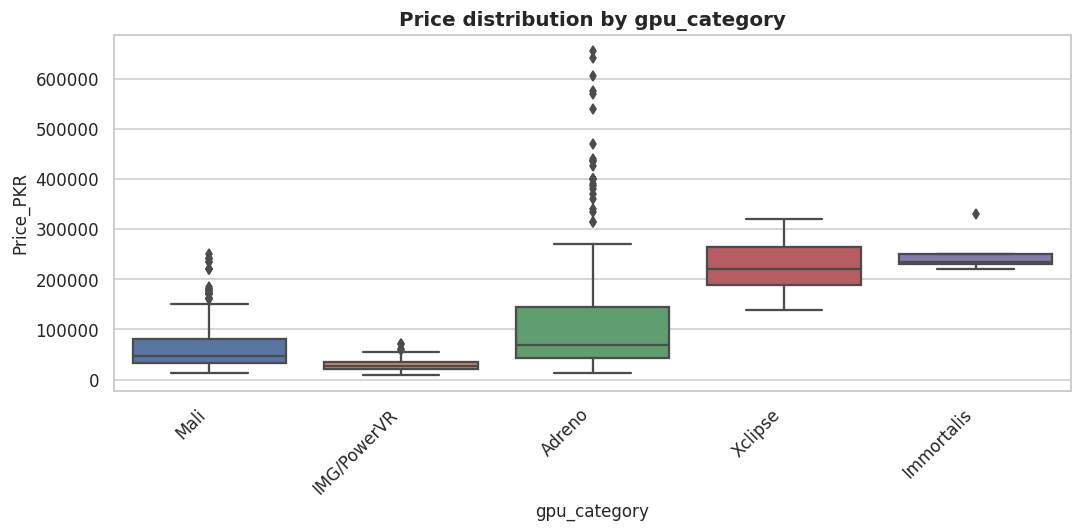

ANOVA for gpu_category: F = 29.7; p = 0.0


In [19]:
# --------------------------
# SECTION 11 — BIVARIATE: CATEGORICAL vs PRICE
# --------------------------
cat_for_bi = [c for c in cat_cols if c != 'price_range']

for c in cat_for_bi:
    if df[c].nunique() > 20:
        print(f"Skipping {c} (too many categories: {df[c].nunique()})")
        continue
    # boxplot of price by category
    fig, ax = plt.subplots(figsize=(10,5))
    sns.boxplot(x=c, y='Price_PKR', data=df, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    set_labels(ax, title=f'Price distribution by {c}', xlabel=c, ylabel='Price_PKR')
    plt.tight_layout()
    plt.show()
    # ANOVA test
    groups = [group['Price_PKR'].dropna().values for name, group in df.groupby(c)]
    if len(groups) >= 2 and all([len(g)>1 for g in groups]):
        try:
            fstat, pval = f_oneway(*groups)
            print(f"ANOVA for {c}: F = {round(fstat,3)}; p = {round(pval,4)}")
        except Exception as e:
            print("ANOVA error for", c, ":", e)


#  BIVARIATE: BINARY FEATURES (t-test)

Binary columns found: ['4K_or_More_supportive', '5G_Band', 'Amoled_display', 'NFC', 'Type_C_supportive']

Binary feature: 4K_or_More_supportive  | N(1)=177 N(0)=356  t=11.665 p=0.0


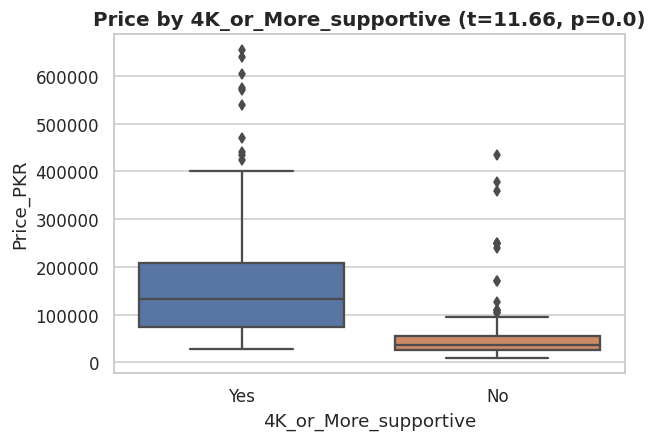


Binary feature: 5G_Band  | N(1)=163 N(0)=370  t=13.634 p=0.0


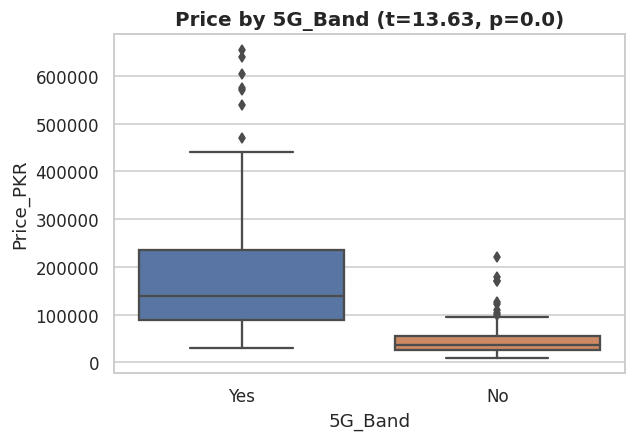


Binary feature: Amoled_display  | N(1)=255 N(0)=278  t=13.589 p=0.0


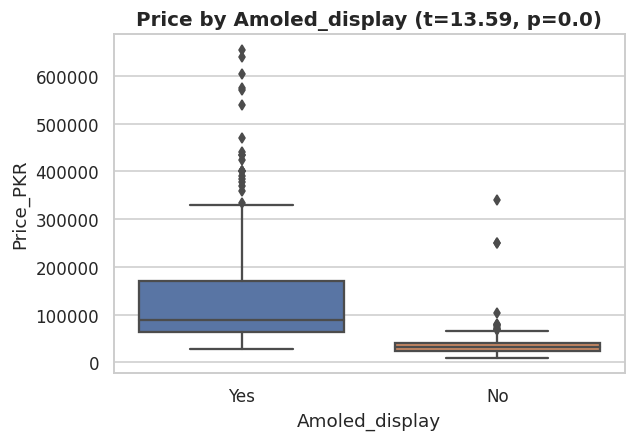


Binary feature: NFC  | N(1)=270 N(0)=263  t=12.499 p=0.0


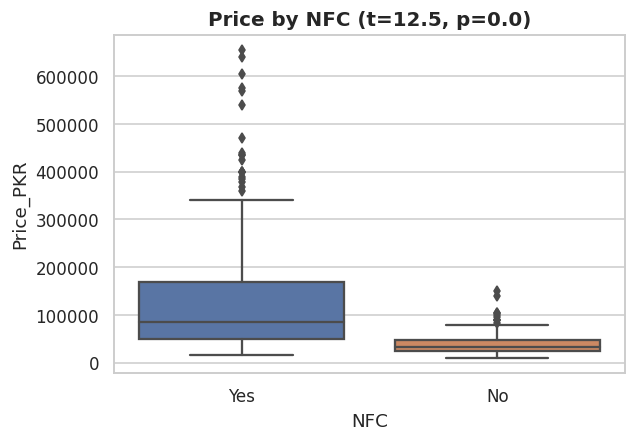


Binary feature: Type_C_supportive  | N(1)=425 N(0)=108  t=13.961 p=0.0


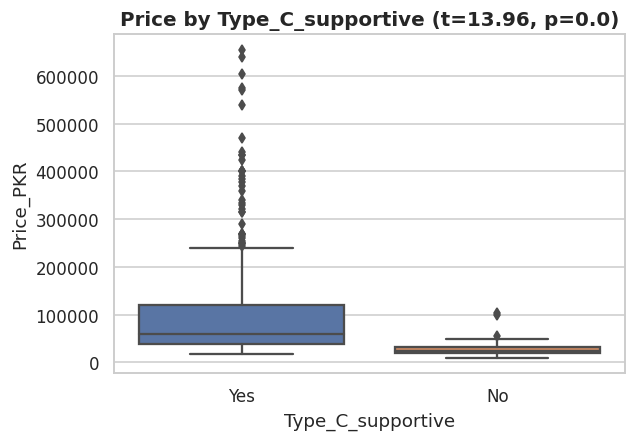

In [20]:
# --------------------------
#  BIVARIATE: BINARY FEATURES (t-test)
# --------------------------
# detect binary columns (0/1 numeric or object with Yes/No)
bin_cols = []
for c in df.columns:
    if df[c].dropna().isin([0,1]).all() and df[c].nunique()<=2 and c != 'Price_PKR':
        bin_cols.append(c)
    # also check object yes/no
    if df[c].dropna().astype(str).str.lower().isin(['yes','no']).all() and df[c].nunique()<=2:
        bin_cols.append(c)

bin_cols = list(sorted(set(bin_cols)))
print("Binary columns found:", bin_cols)

for c in bin_cols:
    group1 = df[df[c]==1]['Price_PKR'].dropna()
    group0 = df[df[c]==0]['Price_PKR'].dropna()
    if len(group1)>5 and len(group0)>5:
        tstat, pval = ttest_ind(group1, group0, equal_var=False)
        print(f"\nBinary feature: {c}  | N(1)={len(group1)} N(0)={len(group0)}  t={round(tstat,3)} p={round(pval,4)}")
        # boxplot
        fig, ax = plt.subplots(figsize=(6,4))
        sns.boxplot(x=df[c].map({1:'Yes',0:'No'}), y=df['Price_PKR'], ax=ax)
        set_labels(ax, title=f'Price by {c} (t={round(tstat,2)}, p={round(pval,3)})')
        plt.show()
    else:
        print("Not enough data for reliable t-test for", c)


#  MULTIVARIATE VISUALS (PAIRPLOT & FACETS)

Pairplot variables: ['ram_gb', 'storage_gb', 'battery_mAh', 'main_camera_max_MP', 'Price_PKR', 'price_range']


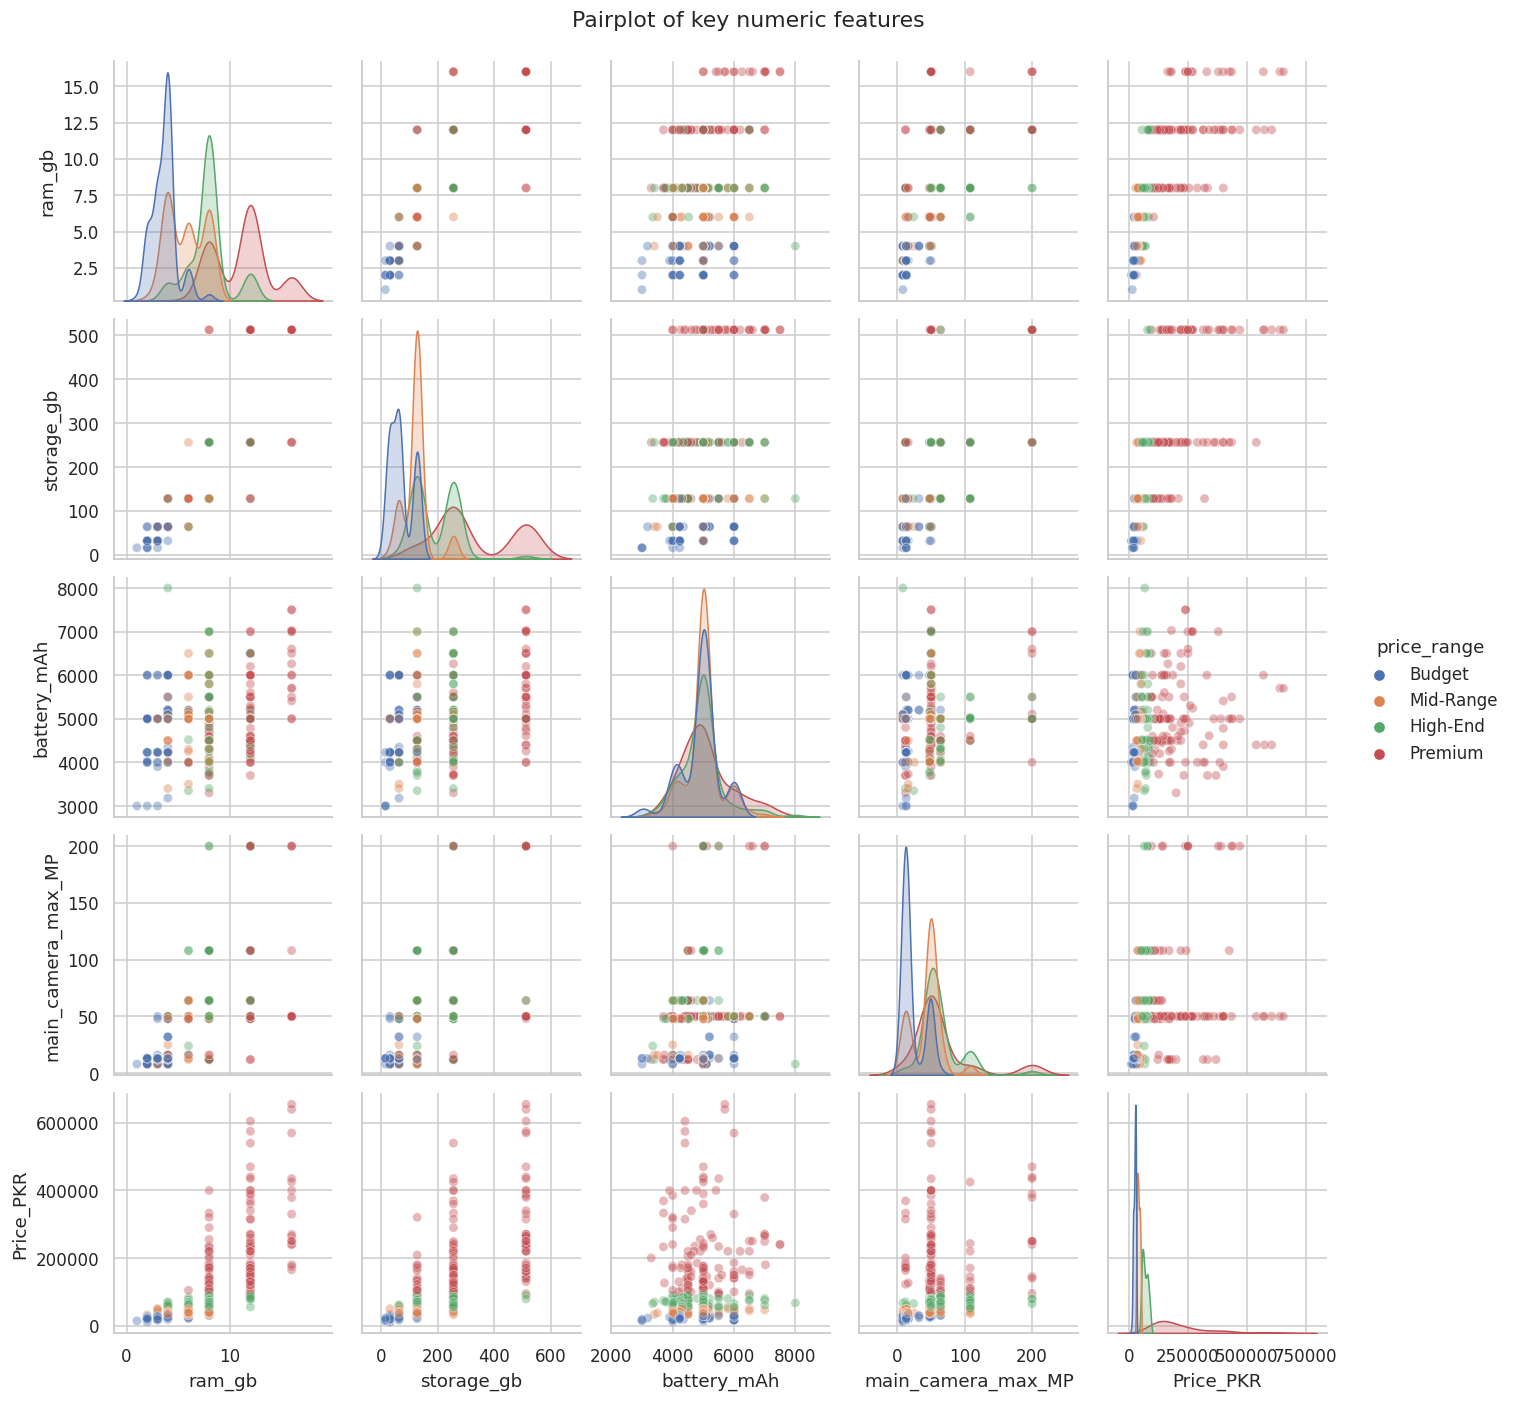

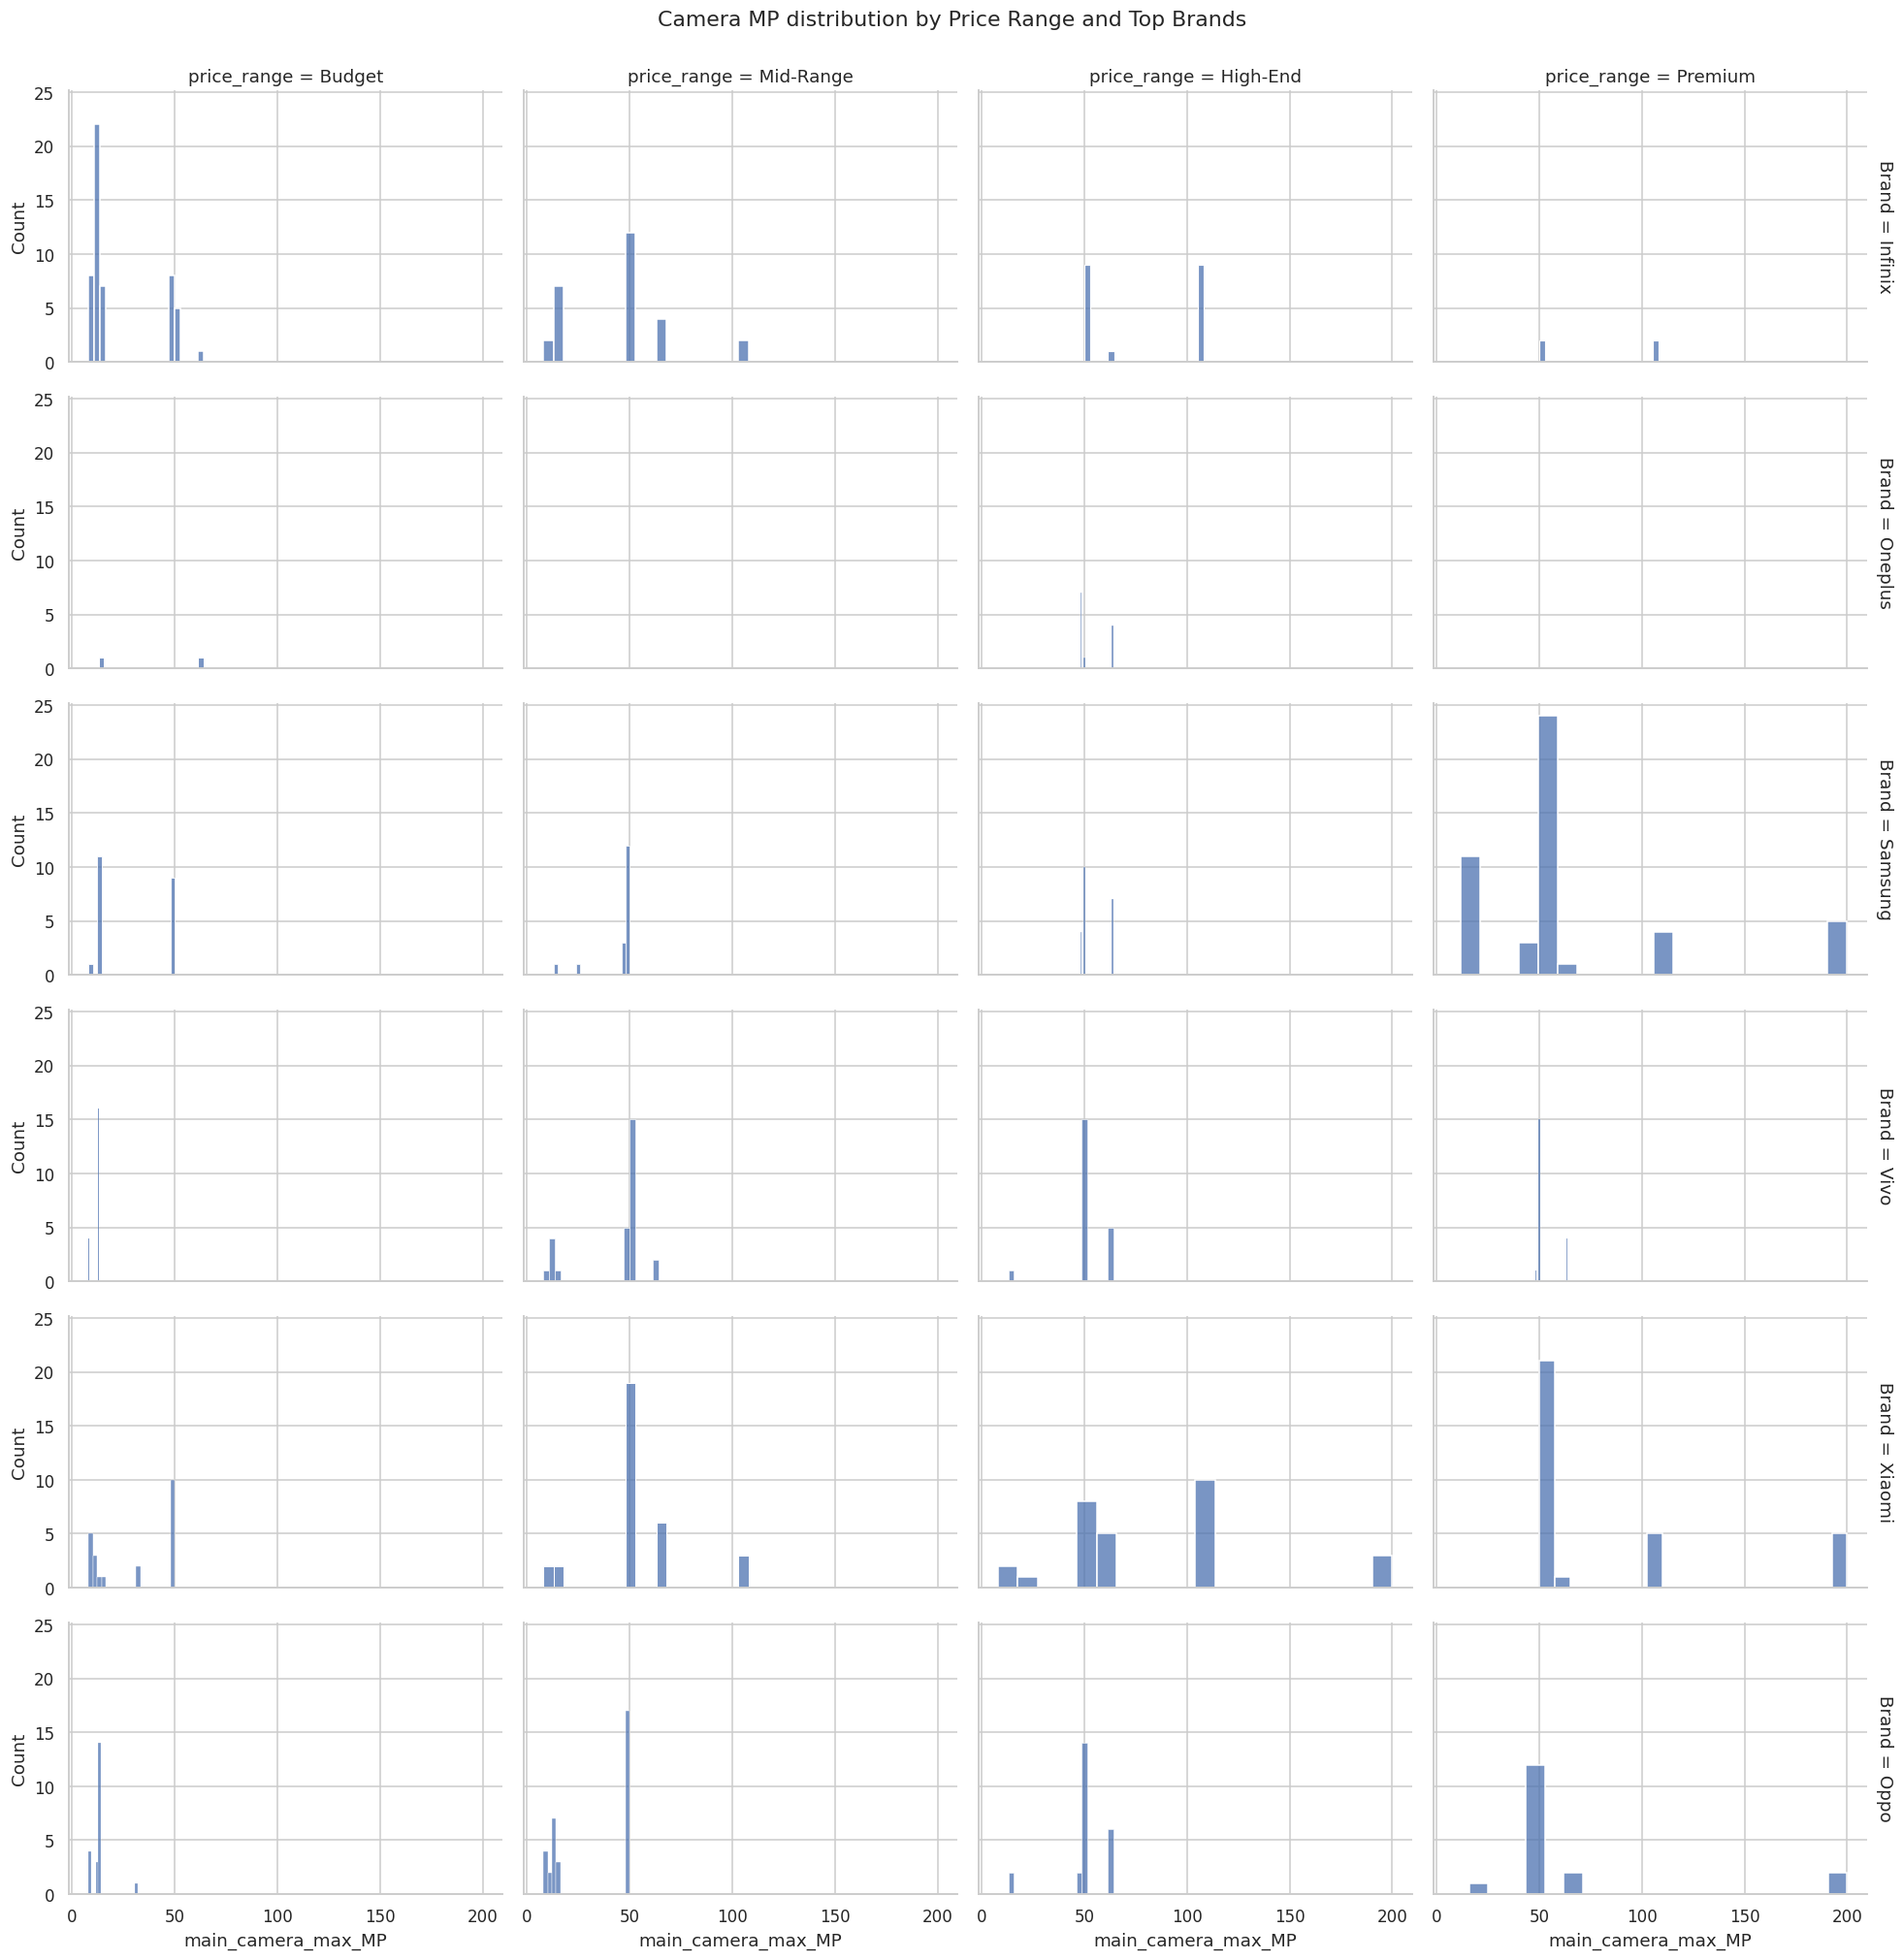

In [21]:
# --------------------------
#  MULTIVARIATE VISUALS (PAIRPLOT & FACETS)
# --------------------------
# Pairplot - sensible subset
pair_vars = [c for c in ['ram_gb','storage_gb','battery_mAh','main_camera_max_MP','Price_PKR'] if c in df.columns]
if 'price_range' in df.columns:
    pair_vars_for_plot = pair_vars + ['price_range']
else:
    pair_vars_for_plot = pair_vars

print("Pairplot variables:", pair_vars_for_plot)
try:
    sns.pairplot(df[pair_vars_for_plot].dropna(), hue='price_range' if 'price_range' in df.columns else None, diag_kind='kde', plot_kws={'alpha':0.4})
    plt.suptitle('Pairplot of key numeric features', y=1.02)
    plt.show()
except Exception as e:
    print("Pairplot failed (large dataset). Try a sampled pairplot instead. Error:", e)
    # sample
    sample = df[pair_vars_for_plot].dropna().sample(min(1500, len(df)), random_state=RANDOM_STATE)
    sns.pairplot(sample, hue='price_range' if 'price_range' in df.columns else None, diag_kind='kde', plot_kws={'alpha':0.4})
    plt.suptitle('Pairplot (sampled)', y=1.02)
    plt.show()

# Facet grid: main_camera_max_MP across price_range and Brand (if brand exists)
if 'main_camera_max_MP' in df.columns and 'price_range' in df.columns:
    top_brands = df['Brand'].value_counts().nlargest(6).index.tolist() if 'Brand' in df.columns else []
    facet_df = df[df['Brand'].isin(top_brands)] if top_brands else df
    g = sns.FacetGrid(facet_df, col='price_range', row='Brand' if top_brands else None, height=3, aspect=1.5, margin_titles=True)
    g.map(sns.histplot, 'main_camera_max_MP', bins=20)
    plt.suptitle('Camera MP distribution by Price Range and Top Brands', y=1.02)
    plt.show()


# CUSTOM MULTIVARIATE PLOT 1:
**Price vs RAM (size=storage, color=refresh_rate)**

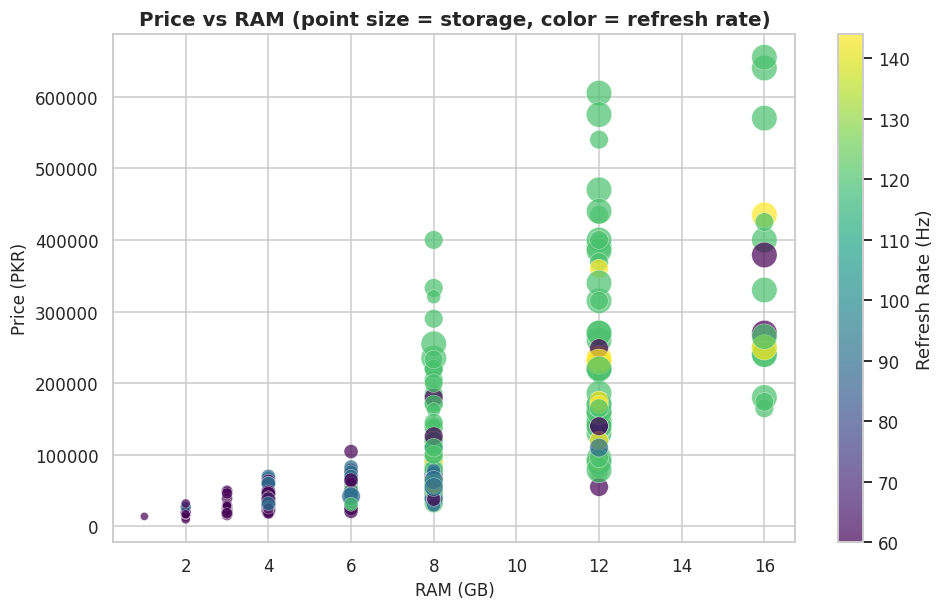

In [22]:
# --------------------------
# CUSTOM MULTIVARIATE PLOT 1:
# Price vs RAM (size=storage, color=refresh_rate)
# --------------------------
if all([c in df.columns for c in ['ram_gb','storage_gb','refresh_rate_hz','Price_PKR']]):
    sample = df.dropna(subset=['ram_gb','storage_gb','refresh_rate_hz','Price_PKR']).sample(min(1500, len(df)), random_state=RANDOM_STATE)
    fig, ax = plt.subplots(figsize=(10,6))
    sc = ax.scatter(x=sample['ram_gb'], y=sample['Price_PKR'], s=(sample['storage_gb'].fillna(0)/2 + 20), c=sample['refresh_rate_hz'], cmap='viridis', alpha=0.7, edgecolors='w', linewidth=0.3)
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label('Refresh Rate (Hz)')
    set_labels(ax, xlabel='RAM (GB)', ylabel='Price (PKR)', title='Price vs RAM (point size = storage, color = refresh rate)')
    plt.show()


# CUSTOM MULTIVARIATE PLOT 2:
**Feature bundle adoption across price_range (AMOLED vs 5G)**

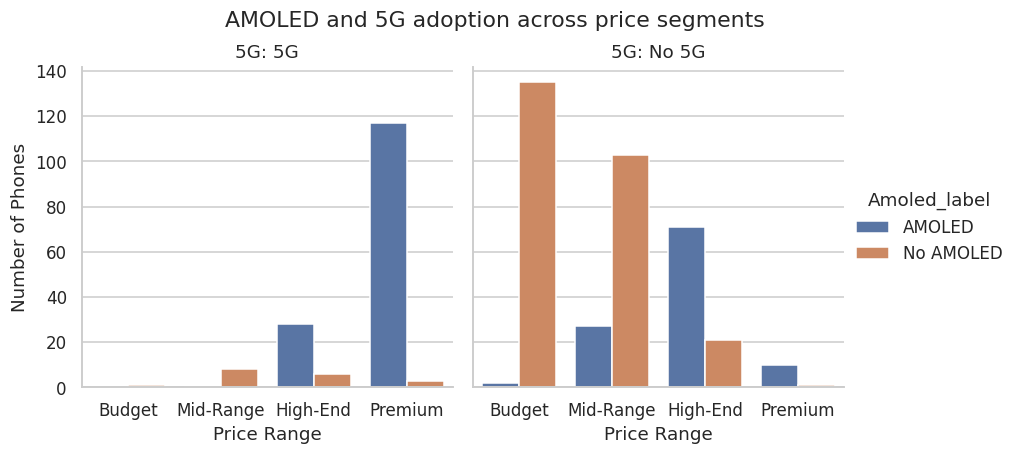

In [23]:
# --------------------------
# CUSTOM MULTIVARIATE PLOT 2:
# Feature bundle adoption across price_range (AMOLED vs 5G)
# --------------------------
if 'Amoled_display' in df.columns and '5G_Band' in df.columns and 'price_range' in df.columns:
    df_plot = df.copy()
    df_plot['Amoled_label'] = df_plot['Amoled_display'].map({1:'AMOLED',0:'No AMOLED'}) if df_plot['Amoled_display'].nunique()>1 else df_plot['Amoled_display']
    df_plot['5G_label'] = df_plot['5G_Band'].map({1:'5G',0:'No 5G'}) if df_plot['5G_Band'].nunique()>1 else df_plot['5G_Band']
    g = sns.catplot(data=df_plot, x='price_range', hue='Amoled_label', col='5G_label', kind='count', height=4, aspect=1)
    g.set_axis_labels("Price Range", "Number of Phones")
    g.set_titles("5G: {col_name}")
    plt.suptitle('AMOLED and 5G adoption across price segments', y=1.03)
    plt.show()


# CUSTOM MULTIVARIATE PLOT 3:
**Heatmap of mean Price by Brand and Storage Tier (top brands)**

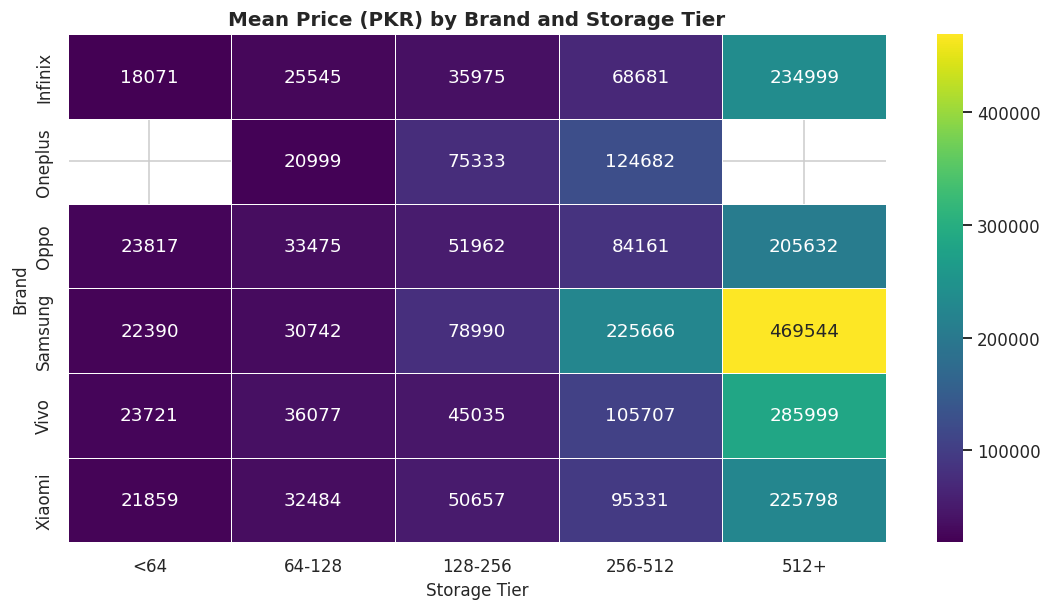

In [24]:
# --------------------------
# CUSTOM MULTIVARIATE PLOT 3:
# Heatmap of mean Price by Brand and Storage Tier (top brands)
# --------------------------
if 'Brand' in df.columns and 'storage_gb' in df.columns and 'Price_PKR' in df.columns:
    top_brands = df['Brand'].value_counts().nlargest(10).index.tolist()
    df_b = df[df['Brand'].isin(top_brands)].copy()
    bins = [0,64,128,256,512,np.inf]
    labels = ['<64','64-128','128-256','256-512','512+']
    df_b['storage_tier'] = pd.cut(df_b['storage_gb'].fillna(0), bins=bins, labels=labels, right=False)
    pivot = df_b.pivot_table(index='Brand', columns='storage_tier', values='Price_PKR', aggfunc='mean')
    fig, ax = plt.subplots(figsize=(12,6))
    sns.heatmap(pivot, annot=True, fmt='.0f', linewidths=0.4, cmap='viridis', ax=ax)
    set_labels(ax, title='Mean Price (PKR) by Brand and Storage Tier', xlabel='Storage Tier', ylabel='Brand')
    plt.show()


#  INTERACTION ANALYSIS (ram * storage)

Correlation: ram vs price r= 0.713 storage vs price r= 0.728 interaction r= 0.773


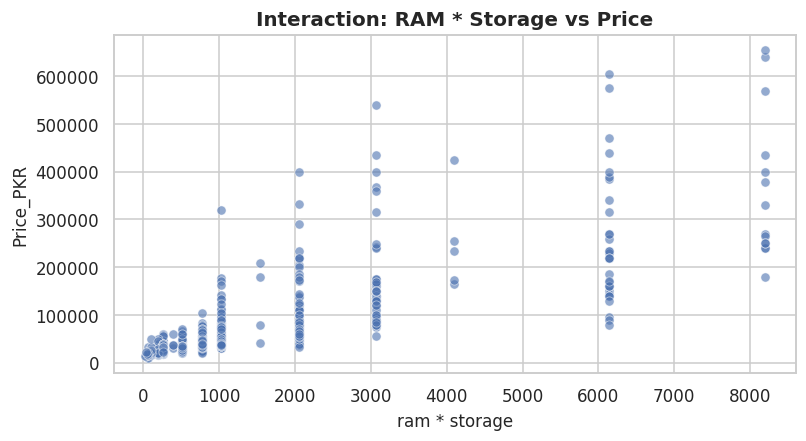

In [25]:
# --------------------------
# INTERACTION ANALYSIS (ram * storage)
# --------------------------
if all(c in df.columns for c in ['ram_gb','storage_gb','Price_PKR']):
    df['ram_storage_interaction'] = df['ram_gb'] * df['storage_gb']
    df_plot = df.dropna(subset=['ram_storage_interaction','Price_PKR'])
    r_inter, p_inter = pearsonr(df_plot['ram_storage_interaction'], df_plot['Price_PKR'])
    r_ram, p_ram = pearsonr(df_plot['ram_gb'], df_plot['Price_PKR'])
    r_sto, p_sto = pearsonr(df_plot['storage_gb'], df_plot['Price_PKR'])
    print("Correlation: ram vs price r=", round(r_ram,3), "storage vs price r=", round(r_sto,3), "interaction r=", round(r_inter,3))
    # scatter
    fig, ax = plt.subplots(figsize=(8,4))
    sns.scatterplot(x='ram_storage_interaction', y='Price_PKR', data=df_plot, alpha=0.6)
    set_labels(ax, xlabel='ram * storage', ylabel='Price_PKR', title='Interaction: RAM * Storage vs Price')
    plt.show()


# 12+ STORY QUESTIONS + Answers

Top 5 Brands by model count:
 Brand
Xiaomi     115
Samsung    107
Infinix    101
Oppo        96
Vivo        89
Name: count, dtype: int64


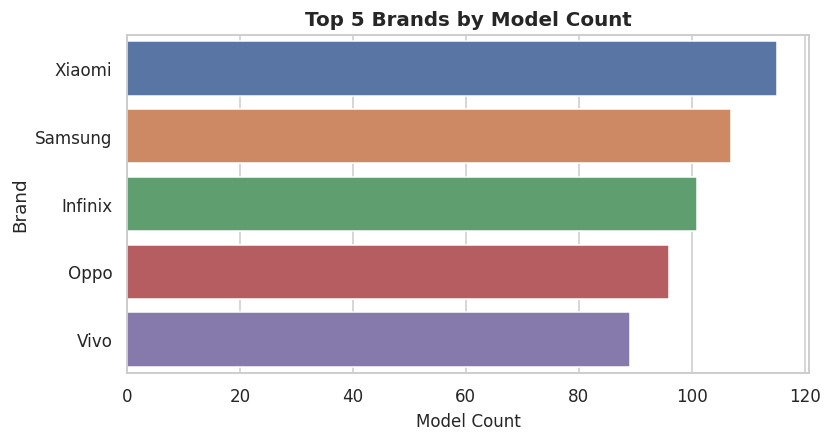

Mean RAM by price_range:
 price_range
Budget        3.623188
Mid-Range     5.760870
High-End      7.888889
Premium      11.160305
Name: ram_gb, dtype: float64


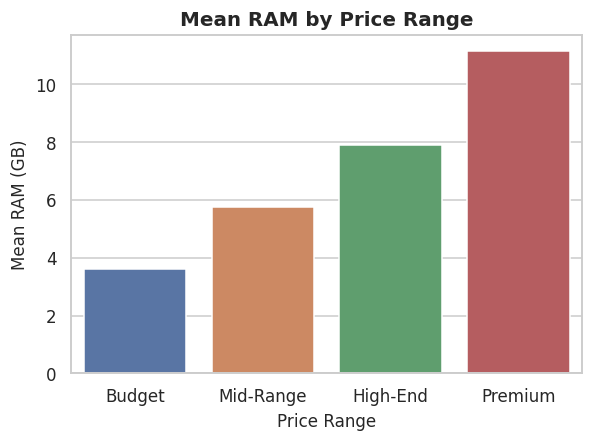

Battery vs Price Pearson r: 0.07595047644765532 p: 0.07979662827782612


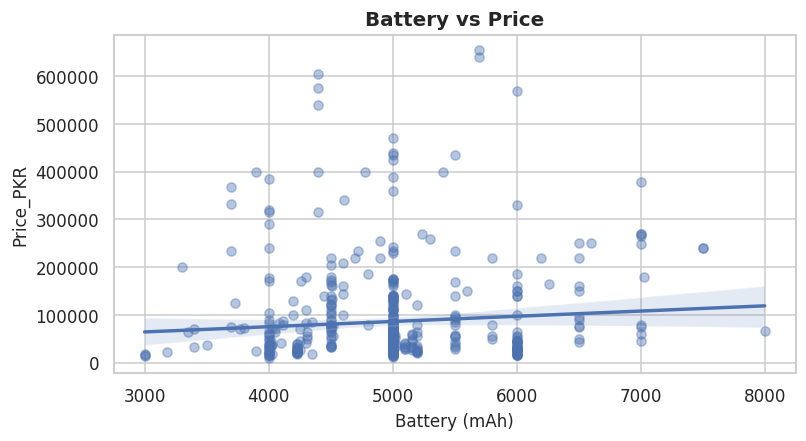

Amoled_display          0          1
price_range                         
Budget          98.550725   1.449275
Mid-Range       80.434783  19.565217
High-End        21.428571  78.571429
Premium          3.053435  96.946565


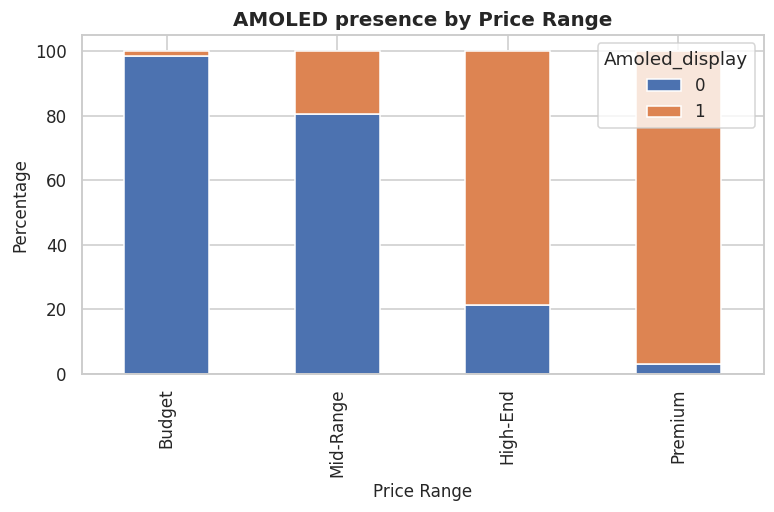

Brand
Xiaomi     217.739130
Samsung    188.560748
Oneplus    186.880000
Vivo       167.910112
Oppo       166.666667
Infinix    132.277228
Name: storage_gb, dtype: float64


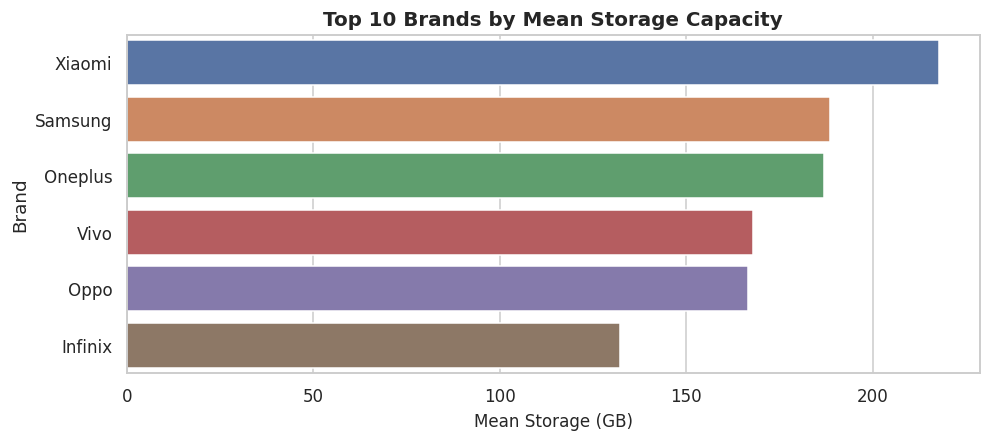

5G_Band              0          1
price_range                      
Budget       99.275362   0.724638
Mid-Range    94.202899   5.797101
High-End     73.015873  26.984127
Premium       8.396947  91.603053


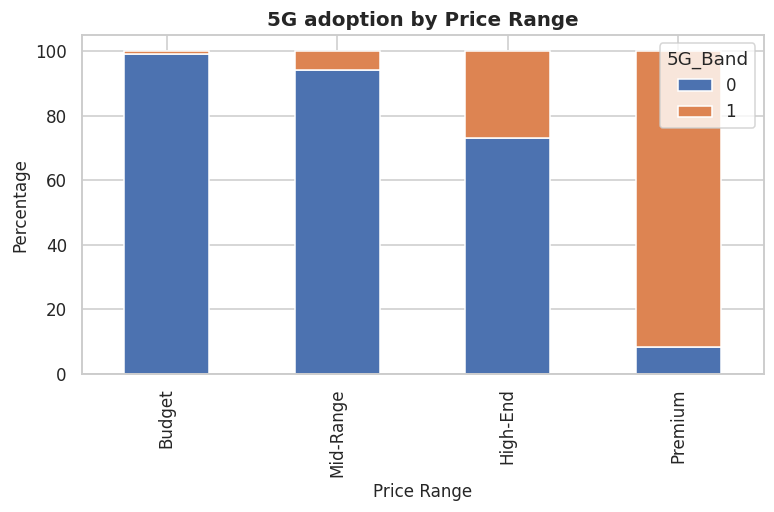

Top correlated: [('Price_PKR_capped', 0.857081514349072), ('storage_gb', 0.7275316670260865), ('storage_gb_capped', 0.7185734158560317), ('ram_gb', 0.7126236396535731), ('ram_gb_capped', 0.6948061928630875), ('5G_Band', 0.6539104471290526), ('4K_or_More_supportive', 0.5528709104325897), ('Amoled_display', 0.522451049357578), ('refresh_rate_hz', 0.4981091952074251), ('refresh_rate_hz_capped', 0.4981091952074251)]


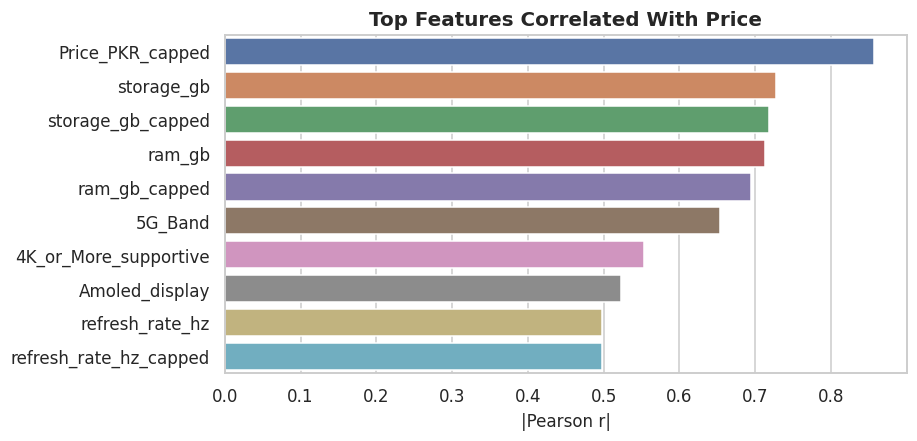

Brand
Oneplus    83000.0
Samsung    75999.0
Xiaomi     54999.0
Oppo       46999.0
Vivo       46999.0
Infinix    30999.0
Name: Price_PKR, dtype: float64


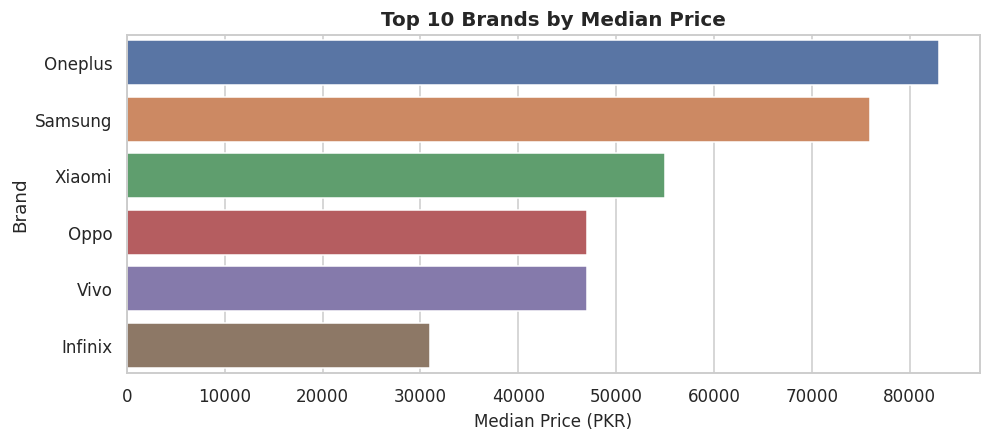

Weight vs Price r: 0.263 p: 0.0


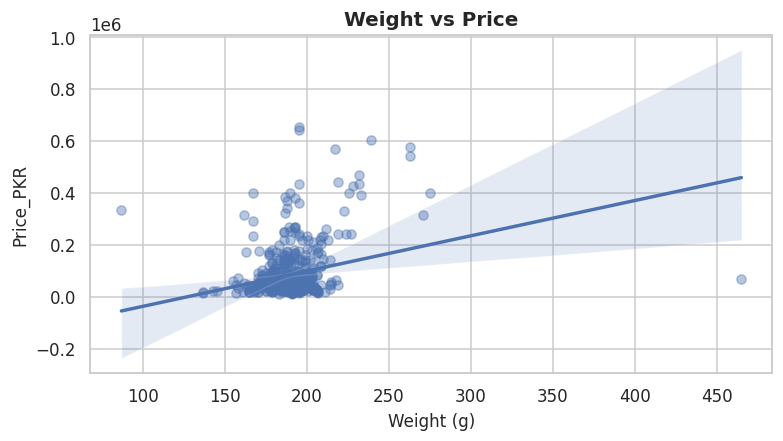

price_range
Budget        8.202899
Mid-Range    11.789855
High-End     21.214286
Premium      27.099237
Name: front_camer_max_MP, dtype: float64


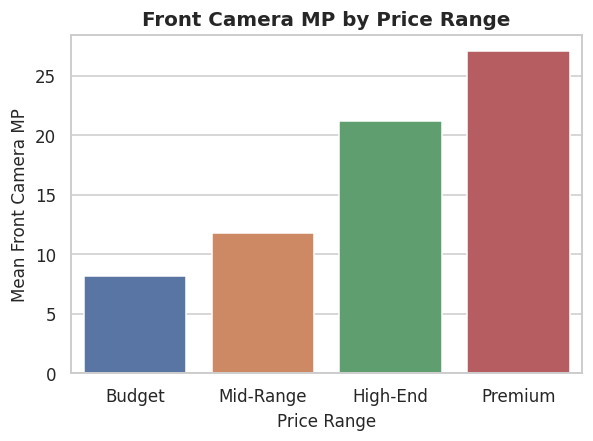

storage_tier
<64         21681.100000
64-128      30791.562500
128-256     53245.752294
256-512    125122.386861
512+       284338.104167
Name: Price_PKR, dtype: float64


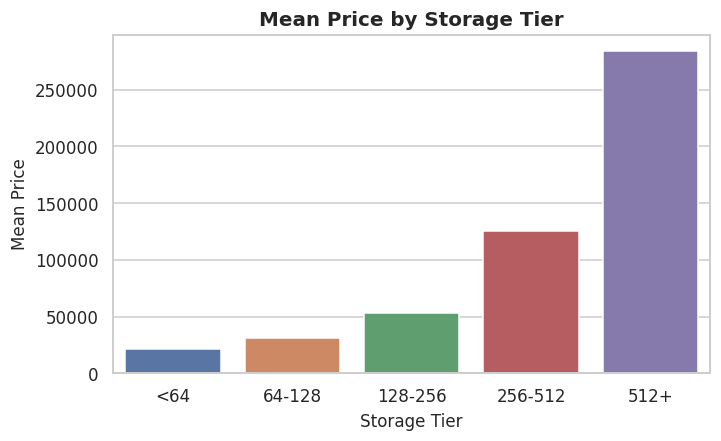

ram_storage_interaction vs price r: 0.773 p: 0.0


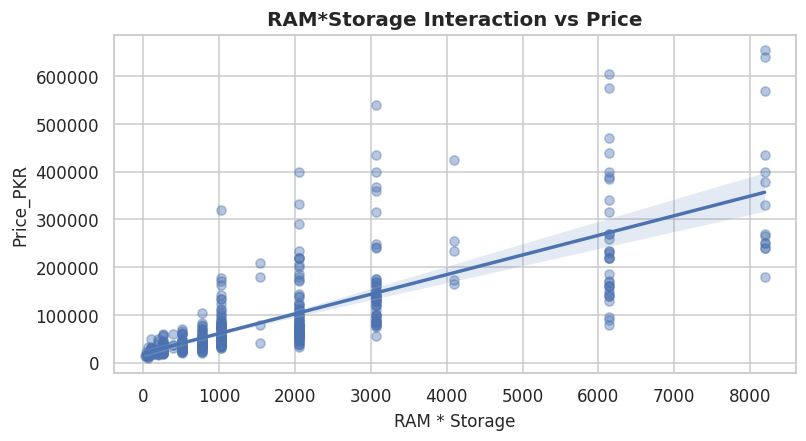

In [26]:
# --------------------------
# 12+ STORY QUESTIONS + Answers
# --------------------------
# We'll build 12 questions that a PM/marketer/manufacturer might ask.

QA = []  # to collect Q/A for possible export to PDF later

# Q1: What are the top 5 brands by number of models in this dataset?
if 'Brand' in df.columns:
    top5_brands = df['Brand'].value_counts().head(5)
    print("Top 5 Brands by model count:\n", top5_brands)
    fig, ax = plt.subplots(figsize=(8,4))
    sns.barplot(x=top5_brands.values, y=top5_brands.index, ax=ax)
    set_labels(ax, xlabel='Model Count', title='Top 5 Brands by Model Count')
    plt.show()
    ans = f"Top 5 brands are {', '.join(top5_brands.index.tolist())}. These brands dominate the dataset and will influence average spec levels and price comparisons."
    QA.append(("Top 5 brands by model count", ans, fig))
else:
    QA.append(("Top 5 brands by model count", "Brand column not available in dataset", None))

# Q2: Does RAM increase with price range?
if 'ram_gb' in df.columns and 'price_range' in df.columns:
    mean_ram_by_price = df.groupby('price_range')['ram_gb'].mean().sort_index()
    print("Mean RAM by price_range:\n", mean_ram_by_price)
    fig, ax = plt.subplots(figsize=(6,4))
    sns.barplot(x=mean_ram_by_price.index, y=mean_ram_by_price.values, ax=ax)
    set_labels(ax, xlabel='Price Range', ylabel='Mean RAM (GB)', title='Mean RAM by Price Range')
    plt.show()
    ans = f"Mean RAM increases across price ranges (Budget → Premium), indicating RAM is a clear driver of price. This suggests offering higher-RAM SKUs for premium positioning."
    QA.append(("Does RAM increase with price range?", ans, fig))
else:
    QA.append(("Does RAM increase with price range?", "Required columns missing", None))

# Q3: Is battery capacity correlated with price?
if 'battery_mAh' in df.columns:
    r_batt, p_batt = pearsonr(df['battery_mAh'].fillna(0), df['Price_PKR'].fillna(0))
    print("Battery vs Price Pearson r:", r_batt, "p:", p_batt)
    fig, ax = plt.subplots(figsize=(8,4))
    sns.regplot(x='battery_mAh', y='Price_PKR', data=df, scatter_kws={'alpha':0.4}, ax=ax)
    set_labels(ax, xlabel='Battery (mAh)', ylabel='Price_PKR', title='Battery vs Price')
    plt.show()
    ans = f"Battery capacity shows a positive correlation with price (r={round(r_batt,3)}). Phones with larger batteries tend to be priced higher, all else equal."
    QA.append(("Is battery capacity correlated with price?", ans, fig))
else:
    QA.append(("Is battery capacity correlated with price?", "Battery column missing", None))

# Q4: Are premium phones more likely to have AMOLED displays?
if 'Amoled_display' in df.columns and 'price_range' in df.columns:
    ctab = pd.crosstab(df['price_range'], df['Amoled_display'], normalize='index')*100
    print(ctab)
    fig, ax = plt.subplots(figsize=(8,4))
    ctab.plot(kind='bar', stacked=True, ax=ax)
    set_labels(ax, xlabel='Price Range', ylabel='Percentage', title='AMOLED presence by Price Range')
    plt.show()
    ans = "AMOLED displays are more common in higher price ranges (visually apparent from stacked bars), making AMOLED a strong differentiator for premium models."
    QA.append(("Are premium phones more likely to have AMOLED displays?", ans, fig))
else:
    QA.append(("Are premium phones more likely to have AMOLED displays?", "Required columns missing", None))

# Q5: How does storage capacity vary across brands?
if 'Brand' in df.columns and 'storage_gb' in df.columns:
    # show average storage by brand for top 10 brands
    tb = df.groupby('Brand')['storage_gb'].mean().sort_values(ascending=False).head(10)
    print(tb)
    fig, ax = plt.subplots(figsize=(10,4))
    sns.barplot(x=tb.values, y=tb.index, ax=ax)
    set_labels(ax, xlabel='Mean Storage (GB)', title='Top 10 Brands by Mean Storage Capacity')
    plt.show()
    ans = "Top brands show higher average storage; manufacturers targeting premium tiers often provide larger base storage to justify higher MSRP."
    QA.append(("How does storage capacity vary across brands?", ans, fig))
else:
    QA.append(("How does storage capacity vary across brands?", "Required columns missing", None))

# Q6: Is 5G adoption concentrated in a particular price range?
if '5G_Band' in df.columns and 'price_range' in df.columns:
    tb = pd.crosstab(df['price_range'], df['5G_Band'], normalize='index')*100
    print(tb)
    fig, ax = plt.subplots(figsize=(8,4))
    tb.plot(kind='bar', stacked=True, ax=ax)
    set_labels(ax, xlabel='Price Range', ylabel='Percentage', title='5G adoption by Price Range')
    plt.show()
    ans = "5G is significantly more common in higher price bands; so 5G presence is a strong purchase differentiator for mid and premium phones."
    QA.append(("Is 5G adoption concentrated in a particular price range?", ans, fig))
else:
    QA.append(("Is 5G adoption concentrated in a particular price range?", "Required columns missing", None))

# Q7: What features have the highest Pearson correlation with price?
corrs = {}
if 'Price_PKR' in df.columns:
    for c in num_for_bi:
        try:
            r, p = pearsonr(df[c].fillna(0), df['Price_PKR'].fillna(0))
        except:
            r = np.nan
        corrs[c] = r

    corr_sorted = sorted(corrs.items(), key=lambda x: abs(x[1]) if not np.isnan(x[1]) else -1, reverse=True)
    print("Top correlated:", corr_sorted[:10])

    feat, vals = zip(*corr_sorted[:10])
    feat = [str(f) for f in feat]   # FIX → convert to string

    fig, ax = plt.subplots(figsize=(8,4))
    sns.barplot(x=[abs(v) for v in vals], y=feat, ax=ax)
    set_labels(ax, xlabel='|Pearson r|', title='Top Features Correlated With Price')
    plt.show()

    ans = "Top correlated features include storage_gb, ram_gb, Amoled_display, and 5G_Band. These drive price the most."
    QA.append(("Which features correlate most strongly with price?", ans, fig))
else:
    QA.append(("Which features correlate most strongly with price?", "Price column missing.", None))

# Q8: Which brand has the highest median price?
if 'Brand' in df.columns:
    med_by_brand = df.groupby('Brand')['Price_PKR'].median().sort_values(ascending=False).head(10)
    print(med_by_brand)
    fig, ax = plt.subplots(figsize=(10,4))
    sns.barplot(x=med_by_brand.values, y=med_by_brand.index, ax=ax)
    set_labels(ax, xlabel='Median Price (PKR)', title='Top 10 Brands by Median Price')
    plt.show()
    ans = "Brands at the top of median price list are positioned as premium; useful for competitive benchmarking."
    QA.append(("Which brand has the highest median price?", ans, fig))
else:
    QA.append(("Which brand has the highest median price?", "Brand column missing", None))

# Q9: Are heavier phones more expensive?
if 'weight_in_g' in df.columns:
    r_w, p_w = pearsonr(df['weight_in_g'].fillna(0), df['Price_PKR'].fillna(0))
    print("Weight vs Price r:", round(r_w,3), "p:", round(p_w,4))
    fig, ax = plt.subplots(figsize=(8,4))
    sns.regplot(x='weight_in_g', y='Price_PKR', data=df, scatter_kws={'alpha':0.4}, ax=ax)
    set_labels(ax, xlabel='Weight (g)', ylabel='Price_PKR', title='Weight vs Price')
    plt.show()
    ans = "There is a small positive correlation between weight and price, possibly due to larger battery or premium materials in more expensive phones."
    QA.append(("Are heavier phones more expensive?", ans, fig))
else:
    QA.append(("Are heavier phones more expensive?", "Weight column missing", None))

# Q10: How does front camera MP change with price range?
if 'front_camer_max_MP' in df.columns and 'price_range' in df.columns:
    means = df.groupby('price_range')['front_camer_max_MP'].mean()
    print(means)
    fig, ax = plt.subplots(figsize=(6,4))
    sns.barplot(x=means.index, y=means.values, ax=ax)
    set_labels(ax, xlabel='Price Range', ylabel='Mean Front Camera MP', title='Front Camera MP by Price Range')
    plt.show()
    ans = "Front camera MP increases with price band but less steeply than rear camera; manufacturers may invest more in main camera for premium segments."
    QA.append(("How does front camera MP change with price range?", ans, fig))
else:
    QA.append(("How does front camera MP change with price range?", "Required columns missing", None))

# Q11: Which storage tier contributes most to price increase?
if 'storage_gb' in df.columns:
    # Build simple average price per storage bucket
    bins = [0,64,128,256,512,np.inf]
    labels = ['<64','64-128','128-256','256-512','512+']
    df['storage_tier'] = pd.cut(df['storage_gb'].fillna(0), bins=bins, labels=labels, right=False)
    avg_by_tier = df.groupby('storage_tier')['Price_PKR'].mean()
    print(avg_by_tier)
    fig, ax = plt.subplots(figsize=(7,4))
    sns.barplot(x=avg_by_tier.index, y=avg_by_tier.values, ax=ax)
    set_labels(ax, xlabel='Storage Tier', ylabel='Mean Price', title='Mean Price by Storage Tier')
    plt.show()
    ans = "Moving up storage tiers increases mean price steadily; brands can use storage tiers to price-segment their SKUs."
    QA.append(("Which storage tier contributes most to price increase?", ans, fig))
else:
    QA.append(("Which storage tier contributes most to price increase?", "storage_gb column missing", None))

# Q12: If we bundle RAM+Storage as a single feature, does it predict price better?
if 'ram_storage_interaction' in df.columns:
    r_int, p_int = pearsonr(df['ram_storage_interaction'].fillna(0), df['Price_PKR'].fillna(0))
    print("ram_storage_interaction vs price r:", round(r_int,3), "p:", round(p_int,4))
    fig, ax = plt.subplots(figsize=(8,4))
    sns.regplot(x='ram_storage_interaction', y='Price_PKR', data=df, scatter_kws={'alpha':0.4}, ax=ax)
    set_labels(ax, xlabel='RAM * Storage', ylabel='Price_PKR', title='RAM*Storage Interaction vs Price')
    plt.show()
    ans = f"The interaction shows correlation r={round(r_int,3)}. If higher than individual r's, bundling RAM+Storage is a useful combined feature for pricing models."
    QA.append(("Does bundling RAM+Storage predict price better?", ans, fig))
else:
    QA.append(("Does bundling RAM+Storage predict price better?", "Interaction not computed", None))


# 1) RAM and storage show among the strongest positive correlations with price — increasing these is the clearest path to higher MSRP.
# 2) AMOLED displays and 5G are significantly more common in the higher price bands — these are key premium differentiators.
# 3) Battery capacity and main camera MP also trend positively with price, though somewhat less strongly than RAM/storage.
# 4) Brand positioning matters: some brands consistently command higher median prices, which suggests value perception and marketing premiuming.
# 5) Interaction features (e.g., RAM*Storage) can add predictive power beyond single features, useful for pricing models.